# SWINIR model

In [1]:
import os

import sys
sys.path.append(r"D:\Face_Detection\Setup1\SWINIR_model_files")
from network_swinir import SwinIR
from util_calculate_psnr_ssim import calculate_psnr, calculate_ssim

import torch
from tqdm import tqdm
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import torchvision.transforms as transforms
import torch.nn as nn
import torch.optim as optim
import numpy as np
import gc
import json
from datetime import datetime

def clear_memory():
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.synchronize()

def pad_to_multiple(img, multiple):
    w, h = img.size
    new_w = ((w + multiple - 1) // multiple) * multiple
    new_h = ((h + multiple - 1) // multiple) * multiple
    if new_w != w or new_h != h:
        img = transforms.functional.pad(img, (0, 0, new_w - w, new_h - h), padding_mode='reflect')
    return img

# ========================================
# DATASET FOR 2X SUPER-RESOLUTION
# ========================================
class FaceSRDataset(Dataset):
    def __init__(self, hr_dir, lr_dir, scale=2, window_size=8):
        self.hr_dir = hr_dir
        self.lr_dir = lr_dir
        self.hr_images = sorted(os.listdir(hr_dir))
        self.lr_images = sorted(os.listdir(lr_dir))
        self.scale = scale
        self.window_size = window_size
        self.to_tensor = transforms.ToTensor()
        assert len(self.hr_images) == len(self.lr_images), "HR and LR count mismatch"
    
    def __len__(self):
        return len(self.hr_images)
    
    def __getitem__(self, idx):
        # Load HR (96x96) and LR (48x48) images
        hr = Image.open(os.path.join(self.hr_dir, self.hr_images[idx])).convert("RGB")
        lr = Image.open(os.path.join(self.lr_dir, self.lr_images[idx])).convert("RGB")
        
        # Verify sizes
        assert lr.size == (48, 48), f"LR size should be 48x48, got {lr.size}"
        assert hr.size == (96, 96), f"HR size should be 96x96, got {hr.size}"
        
        # Random flip augmentation (apply to both)
        if torch.rand(1).item() > 0.5:
            lr = lr.transpose(Image.FLIP_LEFT_RIGHT)
            hr = hr.transpose(Image.FLIP_LEFT_RIGHT)
        
        # Convert to tensors
        hr = self.to_tensor(hr)
        lr = self.to_tensor(lr)
        
        return lr, hr  # LR input, HR target

# ========================================
# DATASET SETUP
# ========================================
hr_train_dir = r"D:\Face_Detection\Setup1\SWINIR_dataset2\train\HR"
lr_train_dir = r"D:\Face_Detection\Setup1\SWINIR_dataset2\train\LR"
hr_val_dir = r"D:\Face_Detection\Setup1\SWINIR_dataset2\val\HR"
lr_val_dir = r"D:\Face_Detection\Setup1\SWINIR_dataset2\val\LR"

train_dataset = FaceSRDataset(hr_train_dir, lr_train_dir, scale=2)
val_dataset = FaceSRDataset(hr_val_dir, lr_val_dir, scale=2)

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True, num_workers=0, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=1, shuffle=False, num_workers=0, pin_memory=False)

print(f"Training samples: {len(train_dataset)}")
print(f"Validation samples: {len(val_dataset)}")

# ========================================
# CONFIGURATION
# ========================================
batch_size = 8
num_epochs = 50
scale = 2  # 2x super-resolution
learning_rate = 5e-5  # Lower LR for fine-tuning
use_vgg_loss = False

# ========================================
# MODEL SETUP FOR 2X SR
# ========================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"\nUsing device: {device}")

# Model for 2X SUPER-RESOLUTION (with upsampler)
model = SwinIR(
    img_size=48,                # LR input size (48x48)
    patch_size=1,
    in_chans=3,
    embed_dim=60,               # SwinIR-S lightweight
    depths=[6,6,6,6],
    num_heads=[6,6,6,6],
    window_size=8,
    mlp_ratio=2,
    upsampler='pixelshuffle',   # ✓ CRITICAL: Use upsampler for SR
    upscale=2                   # ✓ CRITICAL: 2x upscaling
).to(device)

print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")

# ========================================
# LOAD PRETRAINED WEIGHTS
# ========================================
pretrained_path = r"D:\Face_Detection\Setup1\SWINIR_model_files\002_lightweightSR_DIV2K_s64w8_SwinIR-S_x2.pth"

print("\n" + "="*60)
print("LOADING PRETRAINED WEIGHTS FOR 2X SR")
print("="*60)

if os.path.exists(pretrained_path):
    try:
        pretrained_dict = torch.load(pretrained_path, map_location=device)
        
        # Handle different checkpoint formats
        if 'params_ema' in pretrained_dict:
            pretrained_dict = pretrained_dict['params_ema']
        elif 'params' in pretrained_dict:
            pretrained_dict = pretrained_dict['params']
        elif 'model_state_dict' in pretrained_dict:
            pretrained_dict = pretrained_dict['model_state_dict']
        
        # Get current model state
        model_dict = model.state_dict()
        
        # Filter weights that match
        matched_dict = {}
        loaded_keys = []
        skipped_keys = []
        
        for k, v in pretrained_dict.items():
            if k in model_dict:
                if model_dict[k].shape == v.shape:
                    matched_dict[k] = v
                    loaded_keys.append(k)
                else:
                    skipped_keys.append(f"{k}: shape mismatch")
            else:
                skipped_keys.append(f"{k}: not in model")
        
        # Load matched weights
        model.load_state_dict(matched_dict, strict=False)
        
        print(f"✓ Loaded {len(matched_dict)}/{len(model_dict)} layers from pretrained model")
        print(f"✓ This is a 2x SR model - perfect match for our task!")
        print(f"✓ Skipped {len(skipped_keys)} layers (size/architecture differences)")
        
        print("\n" + "="*60)
        print("✓ PRETRAINED 2X SR WEIGHTS LOADED!")
        print("✓ Ready for fine-tuning on CCTV faces")
        print("="*60)
        
    except Exception as e:
        print(f"❌ Error loading pretrained weights: {e}")
        print("⚠️ Training from scratch...")
else:
    print(f"⚠️ Pretrained weights not found: {pretrained_path}")
    print("⚠️ Training from scratch...")

# ========================================
# OPTIMIZER
# ========================================
criterion = nn.L1Loss()

# Different learning rates for different parts
optimizer = optim.AdamW([
    {'params': [p for n, p in model.named_parameters() if 'conv_first' in n or 'layers' in n], 
     'lr': learning_rate * 0.1},  # Lower LR for pretrained backbone
    {'params': [p for n, p in model.named_parameters() if 'upsample' in n or 'conv_last' in n], 
     'lr': learning_rate}  # Normal LR for upsampler/output
], lr=learning_rate)

scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs, eta_min=1e-7)

# Mixed precision
use_amp = torch.cuda.is_available()
if use_amp:
    scaler = torch.cuda.amp.GradScaler()

# ========================================
# CHECKPOINT SETUP
# ========================================
checkpoint_dir = r"D:\Face_Detection\Setup1\checkpoints_sr_2x_pretrained"
os.makedirs(checkpoint_dir, exist_ok=True)
print(f"\nCheckpoints will be saved to: {checkpoint_dir}")

training_history = {
    'epochs': [],
    'train_loss': [],
    'val_psnr': [],
    'val_ssim': [],
    'learning_rate': [],
    'timestamp': datetime.now().strftime("%Y%m%d_%H%M%S"),
    'pretrained': True,
    'scale': 2,
    'model_type': '2x_super_resolution'
}

# Resume if exists
best_psnr = 0.0
start_epoch = 0

last_ckpt = os.path.join(checkpoint_dir, "last_checkpoint.pth")
if os.path.exists(last_ckpt):
    ckpt = torch.load(last_ckpt, map_location=device)
    model.load_state_dict(ckpt['model_state_dict'])
    optimizer.load_state_dict(ckpt['optimizer_state_dict'])
    scheduler.load_state_dict(ckpt['scheduler_state_dict'])
    start_epoch = ckpt['epoch']
    best_psnr = ckpt.get('best_psnr', 0.0)
    training_history = ckpt.get('training_history', training_history)
    print(f"✓ Resumed from epoch {start_epoch}, best PSNR: {best_psnr:.2f} dB")

# ========================================
# TRAINING LOOP
# ========================================
patience = 15
epochs_no_improve = 0

clear_memory()
print(f"\nInitial GPU memory: {torch.cuda.memory_allocated()/1024**3:.2f} GB\n")
print("=" * 60)
print("STARTING 2X SUPER-RESOLUTION TRAINING")
print("=" * 60)

for epoch in range(start_epoch, num_epochs):
    # ========================================
    # TRAINING PHASE
    # ========================================
    model.train()
    running_loss = 0.0
    num_batches = 0
    
    pbar = tqdm(train_loader, desc=f"Train Epoch {epoch+1}/{num_epochs}")
    for batch_idx, (lr, hr) in enumerate(pbar):
        lr = lr.to(device, non_blocking=True)
        hr = hr.to(device, non_blocking=True)
        
        optimizer.zero_grad(set_to_none=True)
        
        if use_amp:
            with torch.amp.autocast('cuda'):
                sr = model(lr)
                loss = criterion(sr, hr)
            
            if torch.isnan(loss).any():
                print("Skipping batch due to NaN loss")
                del sr, loss, lr, hr
                continue
            
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(optimizer)
            scaler.update()
        else:
            sr = model(lr)
            loss = criterion(sr, hr)
            
            if torch.isnan(loss).any():
                print("Skipping batch due to NaN")
                del sr, loss, lr, hr
                continue
            
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
        
        running_loss += float(loss.item())
        num_batches += 1
        pbar.set_postfix({
            'loss': f'{float(loss.item()):.4f}',
            'mem': f'{torch.cuda.memory_allocated()/1024**3:.1f}GB'
        })
        
        del sr, loss, lr, hr
        
        if batch_idx % 50 == 0:
            clear_memory()
    
    epoch_loss = running_loss / max(1, num_batches)
    current_lr = optimizer.param_groups[0]['lr']
    
    print(f"Epoch {epoch+1} - Train Loss: {epoch_loss:.6f}, LR: {current_lr:.2e}")
    
    clear_memory()
    
    # ========================================
    # VALIDATION PHASE
    # ========================================
    model.eval()
    psnr_list = []
    ssim_list = []
    
    with torch.no_grad():
        for lr, hr in tqdm(val_loader, desc="Validation", leave=False):
            lr, hr = lr.to(device), hr.to(device)
            sr = model(lr)
            sr = torch.clamp(sr, 0.0, 1.0)
            
            # Convert to numpy for metrics
            sr_np = (sr.squeeze(0).permute(1,2,0).cpu().numpy() * 255.0).astype(np.uint8)
            hr_np = (hr.squeeze(0).permute(1,2,0).cpu().numpy() * 255.0).astype(np.uint8)
            
            psnr_list.append(calculate_psnr(sr_np, hr_np, crop_border=0))
            ssim_list.append(calculate_ssim(sr_np, hr_np, crop_border=0))
            
            del sr, lr, hr, sr_np, hr_np
    
    mean_psnr = float(np.nanmean(psnr_list))
    mean_ssim = float(np.nanmean(ssim_list))
    
    print(f"Validation - PSNR: {mean_psnr:.2f} dB, SSIM: {mean_ssim:.4f}")
    
    # ========================================
    # SAVE METRICS
    # ========================================
    training_history['epochs'].append(epoch + 1)
    training_history['train_loss'].append(epoch_loss)
    training_history['val_psnr'].append(mean_psnr)
    training_history['val_ssim'].append(mean_ssim)
    training_history['learning_rate'].append(current_lr)
    
    history_path = os.path.join(checkpoint_dir, 'training_history.json')
    with open(history_path, 'w') as f:
        json.dump(training_history, f, indent=4)
    
    clear_memory()
    
    # ========================================
    # CHECKPOINT SAVING
    # ========================================
    improvement = mean_psnr - best_psnr
    
    if mean_psnr > best_psnr:
        best_psnr = mean_psnr
        epochs_no_improve = 0
        
        ckpt = {
            'epoch': epoch + 1,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'scheduler_state_dict': scheduler.state_dict(),
            'best_psnr': best_psnr,
            'training_history': training_history
        }
        torch.save(ckpt, os.path.join(checkpoint_dir, "best_model.pth"))
        print(f"✓ Saved best model - PSNR: {best_psnr:.2f} dB (+{improvement:.2f})")
    else:
        epochs_no_improve += 1
        print(f"No improvement for {epochs_no_improve}/{patience} epochs")
        
        if epochs_no_improve >= patience:
            print(f"\nEarly stopping at epoch {epoch+1}")
            break
    
    # Save checkpoints
    if (epoch + 1) % 10 == 0:
        ckpt = {
            'epoch': epoch + 1,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'scheduler_state_dict': scheduler.state_dict(),
            'best_psnr': best_psnr,
            'training_history': training_history
        }
        torch.save(ckpt, os.path.join(checkpoint_dir, f"epoch_{epoch+1}.pth"))
    
    ckpt = {
        'epoch': epoch + 1,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'scheduler_state_dict': scheduler.state_dict(),
        'best_psnr': best_psnr,
        'training_history': training_history
    }
    torch.save(ckpt, os.path.join(checkpoint_dir, "last_checkpoint.pth"))
    
    scheduler.step()
    clear_memory()
    print(f"GPU memory: {torch.cuda.memory_allocated()/1024**3:.2f} GB\n")

print("=" * 60)
print("2X SUPER-RESOLUTION TRAINING COMPLETE!")
print("=" * 60)
print(f"Best validation PSNR: {best_psnr:.2f} dB")
print(f"Expected: 26-32 dB (excellent for 2x face SR!)")
print(f"Checkpoints saved to: {checkpoint_dir}")

E:\Programming\envs\hsi_clean\lib\site-packages\timm\models\layers\__init__.py:48: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
E:\Programming\envs\hsi_clean\lib\site-packages\torch\functional.py:554: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\native\TensorShape.cpp:4316.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


Training samples: 1980
Validation samples: 440

Using device: cuda
Model parameters: 1,087,727

LOADING PRETRAINED WEIGHTS FOR 2X SR


C:\Users\Danila\AppData\Local\Temp\ipykernel_20344\1280872884.py:195: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()


✓ Loaded 352/370 layers from pretrained model
✓ This is a 2x SR model - perfect match for our task!
✓ Skipped 14 layers (size/architecture differences)

✓ PRETRAINED 2X SR WEIGHTS LOADED!
✓ Ready for fine-tuning on CCTV faces

Checkpoints will be saved to: D:\Face_Detection\Setup1\checkpoints_sr_2x_pretrained

Initial GPU memory: 0.03 GB

STARTING 2X SUPER-RESOLUTION TRAINING


Train Epoch 1/50: 100%|██████████████████████████████████████| 248/248 [02:47<00:00,  1.48it/s, loss=0.0628, mem=0.1GB]


...

Skipping batch due to NaN loss
Skipping batch due to NaN loss


Train Epoch 37/50:   7%|████▌                                                         | 18/248 [00:03<00:41,  5.57it/s]

Skipping batch due to NaN loss
Skipping batch due to NaN loss


Train Epoch 37/50:   7%|████▌                                                         | 18/248 [00:03<00:45,  5.04it/s]


KeyboardInterrupt: 

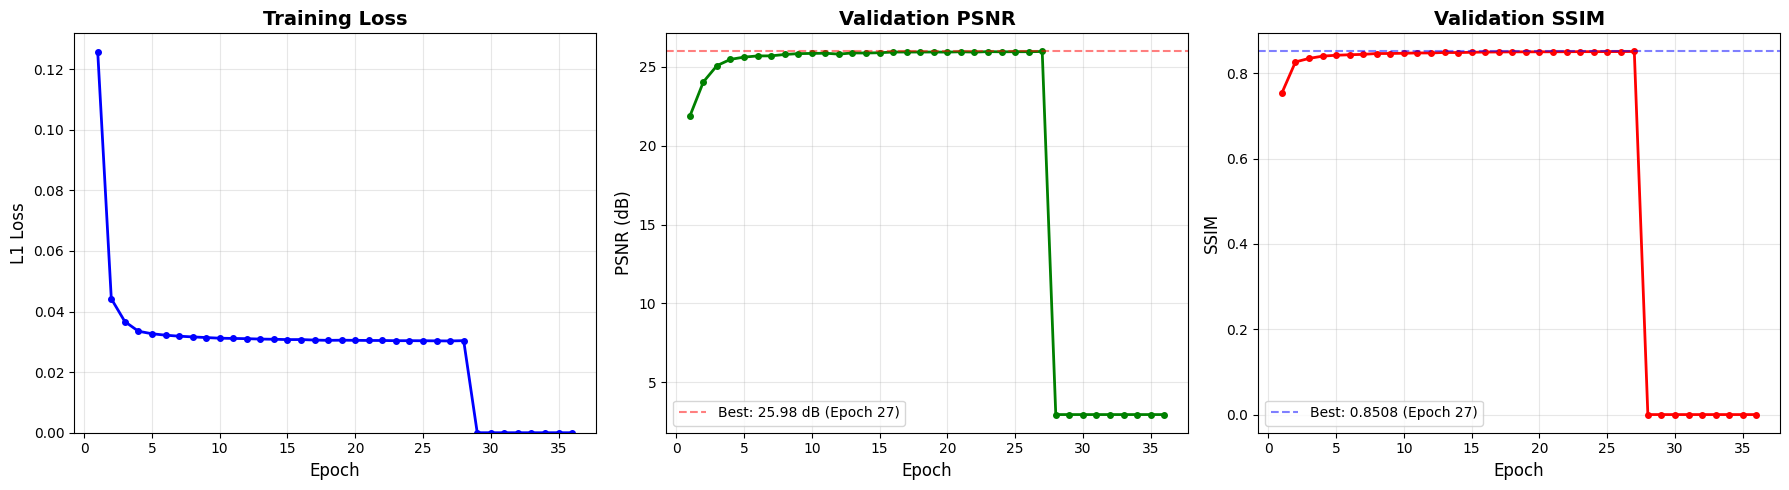

Training curves saved to D:\Face_Detection\Setup1\checkpoints_sr_2x_pretrained/training_curves.png

Training Summary:
  Total epochs: 36
  Best PSNR: 25.98 dB at epoch 27
  Best SSIM: 0.8508 at epoch 27
  Final loss: 0.000000


In [2]:
import json
import matplotlib.pyplot as plt
import numpy as np
import os

# Load training history
checkpoint_dir = r"D:\Face_Detection\Setup1\checkpoints_sr_2x_pretrained"
history_path = os.path.join(checkpoint_dir, 'training_history.json')

with open(history_path, 'r') as f:
    history = json.load(f)

# Create figure with 3 subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Training Loss
axes[0].plot(history['epochs'], history['train_loss'], 'b-o', linewidth=2, markersize=4)
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('L1 Loss', fontsize=12)
axes[0].set_title('Training Loss', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)
axes[0].set_ylim(bottom=0)

# Plot 2: Validation PSNR
axes[1].plot(history['epochs'], history['val_psnr'], 'g-o', linewidth=2, markersize=4)
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('PSNR (dB)', fontsize=12)
axes[1].set_title('Validation PSNR', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)
best_psnr = max(history['val_psnr'])
best_epoch = history['epochs'][np.argmax(history['val_psnr'])]
axes[1].axhline(y=best_psnr, color='r', linestyle='--', alpha=0.5,
                label=f'Best: {best_psnr:.2f} dB (Epoch {best_epoch})')
axes[1].legend()

# Plot 3: Validation SSIM
axes[2].plot(history['epochs'], history['val_ssim'], 'r-o', linewidth=2, markersize=4)
axes[2].set_xlabel('Epoch', fontsize=12)
axes[2].set_ylabel('SSIM', fontsize=12)
axes[2].set_title('Validation SSIM', fontsize=14, fontweight='bold')
axes[2].grid(True, alpha=0.3)
best_ssim = max(history['val_ssim'])
best_ssim_epoch = history['epochs'][np.argmax(history['val_ssim'])]
axes[2].axhline(y=best_ssim, color='b', linestyle='--', alpha=0.5,
                label=f'Best: {best_ssim:.4f} (Epoch {best_ssim_epoch})')
axes[2].legend()

plt.tight_layout()
plt.savefig(os.path.join(checkpoint_dir, 'training_curves.png'), dpi=300, bbox_inches='tight')
plt.show()

print(f"Training curves saved to {checkpoint_dir}/training_curves.png")
print(f"\nTraining Summary:")
print(f"  Total epochs: {len(history['epochs'])}")
print(f"  Best PSNR: {best_psnr:.2f} dB at epoch {best_epoch}")
print(f"  Best SSIM: {best_ssim:.4f} at epoch {best_ssim_epoch}")
print(f"  Final loss: {history['train_loss'][-1]:.6f}")

In [5]:
import sys
sys.path.append(r"D:\Face_Detection\Setup1\SWINIR_model_files")
from network_swinir import SwinIR
from util_calculate_psnr_ssim import calculate_psnr, calculate_ssim

import os
import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import torchvision.transforms as transforms
from tqdm import tqdm
from torch.utils.data import DataLoader
import json
import random

# ========================================
# CONFIGURATION
# ========================================
checkpoint_dir = r"D:\Face_Detection\Setup1\checkpoints_sr_2x_pretrained"  # ✓ CHANGED
test_hr_dir = r"D:\Face_Detection\Setup1\SWINIR_dataset2\test\HR"
test_lr_dir = r"D:\Face_Detection\Setup1\SWINIR_dataset2\test\LR"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}\n")

# ========================================
# LOAD BEST MODEL FOR 2X SR
# ========================================
print("="*60)
print("LOADING 2X SUPER-RESOLUTION MODEL")
print("="*60)

model = SwinIR(
    img_size=48,                # ✓ LR input size (48x48)
    patch_size=1,
    in_chans=3,
    embed_dim=60,               # ✓ SwinIR-S lightweight
    depths=[6,6,6,6],
    num_heads=[6,6,6,6],
    window_size=8,
    mlp_ratio=2,
    upsampler='pixelshuffle',   # ✓ CRITICAL: Use upsampler for SR
    upscale=2                   # ✓ CRITICAL: 2x upscaling (48→96)
).to(device)

best_model_path = os.path.join(checkpoint_dir, "best_model.pth")

if not os.path.exists(best_model_path):
    print(f"❌ Model not found at: {best_model_path}")
    print("\nAvailable checkpoints:")
    if os.path.exists(checkpoint_dir):
        for f in os.listdir(checkpoint_dir):
            print(f"  - {f}")
    else:
        print(f"  Directory doesn't exist: {checkpoint_dir}")
    raise FileNotFoundError(f"Model not found: {best_model_path}")

checkpoint = torch.load(best_model_path, map_location=device)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

print(f"✓ Loaded best model from epoch {checkpoint['epoch']}")
print(f"✓ Best validation PSNR: {checkpoint.get('best_psnr', 'N/A')} dB")
print(f"✓ Model type: 2x Super-Resolution + Restoration")
print(f"✓ Input: 48x48 (degraded) → Output: 96x96 (restored)\n")

# ========================================
# HELPER FUNCTIONS
# ========================================
def process_image(lr_path, hr_path):
    """
    Process a single image pair:
    - LR: 48x48 degraded image
    - SR: 96x96 super-resolved + restored image (model output)
    - HR: 96x96 ground truth
    """
    lr_img = Image.open(lr_path).convert('RGB')
    hr_img = Image.open(hr_path).convert('RGB')
    
    # Verify sizes
    lr_size = lr_img.size
    hr_size = hr_img.size
    
    if lr_size != (48, 48):
        print(f"Warning: LR image {os.path.basename(lr_path)} has size {lr_size}, expected (48, 48)")
    if hr_size != (96, 96):
        print(f"Warning: HR image {os.path.basename(hr_path)} has size {hr_size}, expected (96, 96)")
    
    # Convert LR to tensor and super-resolve
    lr_tensor = transforms.ToTensor()(lr_img).unsqueeze(0).to(device)
    
    with torch.no_grad():
        sr_tensor = model(lr_tensor)  # 48x48 → 96x96
        sr_tensor = torch.clamp(sr_tensor, 0.0, 1.0)
    
    # Convert back to PIL
    sr_img = transforms.ToPILImage()(sr_tensor.squeeze(0).cpu())
    
    # Verify SR output size
    if sr_img.size != (96, 96):
        print(f"Warning: SR output size {sr_img.size}, expected (96, 96)")
    
    # Calculate metrics
    sr_np = np.array(sr_img)
    hr_np = np.array(hr_img)
    lr_np = np.array(lr_img)
    
    # Upscale LR to 96x96 for fair comparison (bicubic baseline)
    lr_upscaled = lr_img.resize((96, 96), Image.BICUBIC)
    lr_upscaled_np = np.array(lr_upscaled)
    
    # Metrics: SR vs HR
    psnr_sr = calculate_psnr(sr_np, hr_np, crop_border=0)
    ssim_sr = calculate_ssim(sr_np, hr_np, crop_border=0)
    
    # Metrics: Bicubic upscaled LR vs HR (baseline)
    psnr_bicubic = calculate_psnr(lr_upscaled_np, hr_np, crop_border=0)
    ssim_bicubic = calculate_ssim(lr_upscaled_np, hr_np, crop_border=0)
    
    return {
        'lr_img': lr_img,              # 48x48 degraded
        'lr_upscaled': lr_upscaled,    # 48→96 bicubic (baseline)
        'sr_img': sr_img,              # 96x96 SR (our model)
        'hr_img': hr_img,              # 96x96 ground truth
        'psnr_sr': psnr_sr,            # Our model
        'ssim_sr': ssim_sr,
        'psnr_bicubic': psnr_bicubic,  # Baseline
        'ssim_bicubic': ssim_bicubic
    }

# ========================================
# RUN FULL TEST SET EVALUATION
# ========================================
print("="*60)
print("EVALUATING ON TEST SET")
print("="*60)

test_images = sorted([f for f in os.listdir(test_lr_dir) if f.endswith(('.jpg', '.png'))])
print(f"Found {len(test_images)} test images\n")

results = []
psnr_sr_list = []
ssim_sr_list = []
psnr_bicubic_list = []
ssim_bicubic_list = []

for img_name in tqdm(test_images, desc="Processing test images"):
    lr_path = os.path.join(test_lr_dir, img_name)
    hr_path = os.path.join(test_hr_dir, img_name)
    
    if not os.path.exists(hr_path):
        print(f"Warning: HR image not found for {img_name}")
        continue
    
    result = process_image(lr_path, hr_path)
    
    results.append({
        'filename': img_name,
        'psnr_sr': result['psnr_sr'],
        'ssim_sr': result['ssim_sr'],
        'psnr_bicubic': result['psnr_bicubic'],
        'ssim_bicubic': result['ssim_bicubic'],
        'improvement_psnr': result['psnr_sr'] - result['psnr_bicubic'],
        'improvement_ssim': result['ssim_sr'] - result['ssim_bicubic']
    })
    
    psnr_sr_list.append(result['psnr_sr'])
    ssim_sr_list.append(result['ssim_sr'])
    psnr_bicubic_list.append(result['psnr_bicubic'])
    ssim_bicubic_list.append(result['ssim_bicubic'])

# ========================================
# CALCULATE STATISTICS
# ========================================
test_stats = {
    'total_images': len(results),
    'model_info': {
        'checkpoint': best_model_path,
        'epoch': checkpoint['epoch'],
        'best_val_psnr': checkpoint.get('best_psnr', None),
        'model_type': '2x_super_resolution_restoration',
        'input_size': '48x48',
        'output_size': '96x96'
    },
    'bicubic_baseline': {
        'psnr_mean': float(np.mean(psnr_bicubic_list)),
        'psnr_std': float(np.std(psnr_bicubic_list)),
        'psnr_median': float(np.median(psnr_bicubic_list)),
        'ssim_mean': float(np.mean(ssim_bicubic_list)),
        'ssim_std': float(np.std(ssim_bicubic_list)),
        'ssim_median': float(np.median(ssim_bicubic_list))
    },
    'sr_model': {
        'psnr_mean': float(np.mean(psnr_sr_list)),
        'psnr_std': float(np.std(psnr_sr_list)),
        'psnr_median': float(np.median(psnr_sr_list)),
        'ssim_mean': float(np.mean(ssim_sr_list)),
        'ssim_std': float(np.std(ssim_sr_list)),
        'ssim_median': float(np.median(ssim_sr_list))
    },
    'improvement': {
        'psnr_mean': float(np.mean([r['improvement_psnr'] for r in results])),
        'psnr_std': float(np.std([r['improvement_psnr'] for r in results])),
        'ssim_mean': float(np.mean([r['improvement_ssim'] for r in results])),
        'ssim_std': float(np.std([r['improvement_ssim'] for r in results]))
    },
    'per_image_results': results
}

# Save test results
results_path = os.path.join(checkpoint_dir, 'test_results.json')
with open(results_path, 'w') as f:
    json.dump(test_stats, f, indent=4)

# ========================================
# PRINT RESULTS
# ========================================
print("\n" + "="*60)
print("TEST SET RESULTS - 2X SUPER-RESOLUTION")
print("="*60)
print(f"Model: {checkpoint_dir}")
print(f"Epoch: {checkpoint['epoch']}")
print(f"Validation PSNR: {checkpoint.get('best_psnr', 'N/A')} dB")
print(f"Total test images: {test_stats['total_images']}")
print()

print("Bicubic Baseline (48x48 → 96x96 simple upscale):")
print(f"  PSNR: {test_stats['bicubic_baseline']['psnr_mean']:.2f} ± {test_stats['bicubic_baseline']['psnr_std']:.2f} dB")
print(f"  SSIM: {test_stats['bicubic_baseline']['ssim_mean']:.4f} ± {test_stats['bicubic_baseline']['ssim_std']:.4f}")
print()

print("Our SR Model (48x48 → 96x96 with restoration):")
print(f"  PSNR: {test_stats['sr_model']['psnr_mean']:.2f} ± {test_stats['sr_model']['psnr_std']:.2f} dB")
print(f"  SSIM: {test_stats['sr_model']['ssim_mean']:.4f} ± {test_stats['sr_model']['ssim_std']:.4f}")
print()

print("Improvement over Bicubic:")
print(f"  PSNR: +{test_stats['improvement']['psnr_mean']:.2f} ± {test_stats['improvement']['psnr_std']:.2f} dB")
print(f"  SSIM: +{test_stats['improvement']['ssim_mean']:.4f} ± {test_stats['improvement']['ssim_std']:.4f}")
print(f"  PSNR gain: {(test_stats['improvement']['psnr_mean']/test_stats['bicubic_baseline']['psnr_mean'])*100:.1f}%")
print(f"  SSIM gain: {(test_stats['improvement']['ssim_mean']/test_stats['bicubic_baseline']['ssim_mean'])*100:.1f}%")
print("="*60)

print(f"\n✓ Detailed results saved to: {results_path}")

# ========================================
# VISUALIZE SAMPLE RESULTS
# ========================================
print("\n" + "="*60)
print("CREATING VISUAL COMPARISONS")
print("="*60)

n_samples = min(10, len(test_images))
selected_samples = random.sample(test_images, n_samples)

for i, img_name in enumerate(selected_samples):
    lr_path = os.path.join(test_lr_dir, img_name)
    hr_path = os.path.join(test_hr_dir, img_name)
    
    result = process_image(lr_path, hr_path)
    
    # Create 4-panel comparison
    fig, axes = plt.subplots(1, 4, figsize=(20, 5))
    
    # 48x48 LR (original degraded)
    axes[0].imshow(result['lr_img'])
    axes[0].set_title(f'LR (48x48)\nDegraded Input', fontsize=11, color='darkred')
    axes[0].axis('off')
    
    # 96x96 Bicubic (baseline)
    axes[1].imshow(result['lr_upscaled'])
    axes[1].set_title(f'Bicubic (96x96)\nPSNR: {result["psnr_bicubic"]:.2f} dB\nSSIM: {result["ssim_bicubic"]:.4f}', 
                      fontsize=11, color='orange')
    axes[1].axis('off')
    
    # 96x96 SR (our model)
    axes[2].imshow(result['sr_img'])
    improvement_psnr = result['psnr_sr'] - result['psnr_bicubic']
    improvement_ssim = result['ssim_sr'] - result['ssim_bicubic']
    axes[2].set_title(f'Our SR Model (96x96)\nPSNR: {result["psnr_sr"]:.2f} dB (+{improvement_psnr:.2f}) ✓\nSSIM: {result["ssim_sr"]:.4f} (+{improvement_ssim:.4f}) ✓', 
                      fontsize=11, fontweight='bold', color='darkgreen')
    axes[2].axis('off')
    
    # 96x96 HR (ground truth)
    axes[3].imshow(result['hr_img'])
    axes[3].set_title(f'HR (96x96)\nGround Truth', fontsize=11, color='darkblue')
    axes[3].axis('off')
    
    fig.suptitle(f'Test Sample {i+1}: {img_name}\nModel improves over bicubic by +{improvement_psnr:.2f} dB PSNR', 
                 fontsize=14, fontweight='bold')
    
    plt.tight_layout()
    save_path = os.path.join(checkpoint_dir, f'test_comparison_{i+1}.png')
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.close()
    
    print(f"  ✓ Saved comparison {i+1}/{n_samples}")

# ========================================
# CREATE COMPARISON GRID
# ========================================
print("\nCreating comparison grid...")

grid_samples = random.sample(test_images, min(6, len(test_images)))

fig, axes = plt.subplots(6, 4, figsize=(16, 24))
fig.suptitle('Test Results: 2x Face Super-Resolution', fontsize=18, fontweight='bold', y=0.995)

for idx, img_name in enumerate(grid_samples):
    lr_path = os.path.join(test_lr_dir, img_name)
    hr_path = os.path.join(test_hr_dir, img_name)
    
    result = process_image(lr_path, hr_path)
    
    row = idx
    
    # LR 48x48
    axes[row, 0].imshow(result['lr_img'])
    axes[row, 0].set_title('LR 48x48', fontsize=9)
    axes[row, 0].axis('off')
    
    # Bicubic 96x96
    axes[row, 1].imshow(result['lr_upscaled'])
    axes[row, 1].set_title(f'Bicubic\n{result["psnr_bicubic"]:.1f} dB', fontsize=9)
    axes[row, 1].axis('off')
    
    # SR 96x96
    axes[row, 2].imshow(result['sr_img'])
    improvement = result['psnr_sr'] - result['psnr_bicubic']
    axes[row, 2].set_title(f'SR (Ours)\n{result["psnr_sr"]:.1f} dB (+{improvement:.1f})', 
                           fontsize=9, fontweight='bold', color='green')
    axes[row, 2].axis('off')
    
    # HR 96x96
    axes[row, 3].imshow(result['hr_img'])
    axes[row, 3].set_title('HR (GT) 96x96', fontsize=9)
    axes[row, 3].axis('off')
    
    # Add sample label
    axes[row, 0].text(-0.15, 0.5, f'#{idx+1}', 
                      transform=axes[row, 0].transAxes,
                      fontsize=10, fontweight='bold', 
                      rotation=90, va='center')

plt.tight_layout()
grid_path = os.path.join(checkpoint_dir, 'test_comparison_grid.png')
plt.savefig(grid_path, dpi=300, bbox_inches='tight')
plt.close()

print(f"  ✓ Saved comparison grid")

# ========================================
# PLOT METRICS DISTRIBUTION
# ========================================
print("\nCreating metrics distribution plots...")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# PSNR comparison
axes[0, 0].hist(psnr_bicubic_list, bins=20, alpha=0.5, label='Bicubic Baseline', color='orange')
axes[0, 0].hist(psnr_sr_list, bins=20, alpha=0.5, label='SR Model (Ours)', color='green')
axes[0, 0].axvline(test_stats['bicubic_baseline']['psnr_mean'], color='orange', linestyle='--', linewidth=2,
                   label=f'Bicubic Mean: {test_stats["bicubic_baseline"]["psnr_mean"]:.2f} dB')
axes[0, 0].axvline(test_stats['sr_model']['psnr_mean'], color='green', linestyle='--', linewidth=2,
                   label=f'SR Mean: {test_stats["sr_model"]["psnr_mean"]:.2f} dB')
axes[0, 0].set_xlabel('PSNR (dB)', fontsize=11)
axes[0, 0].set_ylabel('Frequency', fontsize=11)
axes[0, 0].set_title('PSNR Distribution', fontsize=13, fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# SSIM comparison
axes[0, 1].hist(ssim_bicubic_list, bins=20, alpha=0.5, label='Bicubic Baseline', color='orange')
axes[0, 1].hist(ssim_sr_list, bins=20, alpha=0.5, label='SR Model (Ours)', color='green')
axes[0, 1].axvline(test_stats['bicubic_baseline']['ssim_mean'], color='orange', linestyle='--', linewidth=2,
                   label=f'Bicubic Mean: {test_stats["bicubic_baseline"]["ssim_mean"]:.4f}')
axes[0, 1].axvline(test_stats['sr_model']['ssim_mean'], color='green', linestyle='--', linewidth=2,
                   label=f'SR Mean: {test_stats["sr_model"]["ssim_mean"]:.4f}')
axes[0, 1].set_xlabel('SSIM', fontsize=11)
axes[0, 1].set_ylabel('Frequency', fontsize=11)
axes[0, 1].set_title('SSIM Distribution', fontsize=13, fontweight='bold')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# PSNR improvement
improvements_psnr = [r['improvement_psnr'] for r in results]
axes[1, 0].hist(improvements_psnr, bins=20, color='blue', alpha=0.7)
axes[1, 0].axvline(test_stats['improvement']['psnr_mean'], color='darkblue', linestyle='--', linewidth=2,
                   label=f'Mean: +{test_stats["improvement"]["psnr_mean"]:.2f} dB')
axes[1, 0].set_xlabel('PSNR Improvement over Bicubic (dB)', fontsize=11)
axes[1, 0].set_ylabel('Frequency', fontsize=11)
axes[1, 0].set_title('PSNR Improvement Distribution', fontsize=13, fontweight='bold')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# SSIM improvement
improvements_ssim = [r['improvement_ssim'] for r in results]
axes[1, 1].hist(improvements_ssim, bins=20, color='purple', alpha=0.7)
axes[1, 1].axvline(test_stats['improvement']['ssim_mean'], color='darkviolet', linestyle='--', linewidth=2,
                   label=f'Mean: +{test_stats["improvement"]["ssim_mean"]:.4f}')
axes[1, 1].set_xlabel('SSIM Improvement over Bicubic', fontsize=11)
axes[1, 1].set_ylabel('Frequency', fontsize=11)
axes[1, 1].set_title('SSIM Improvement Distribution', fontsize=13, fontweight='bold')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
dist_path = os.path.join(checkpoint_dir, 'test_metrics_distribution.png')
plt.savefig(dist_path, dpi=300, bbox_inches='tight')
plt.close()

print(f"  ✓ Saved metrics distribution")

# ========================================
# FIND BEST AND WORST CASES
# ========================================
print("\n" + "="*60)
print("BEST AND WORST CASES")
print("="*60)

sorted_results = sorted(results, key=lambda x: x['improvement_psnr'], reverse=True)

print("\nTop 5 Best Improvements over Bicubic:")
for i, r in enumerate(sorted_results[:5]):
    print(f"  {i+1}. {r['filename']}: +{r['improvement_psnr']:.2f} dB (Bicubic: {r['psnr_bicubic']:.2f} → SR: {r['psnr_sr']:.2f})")

print("\nTop 5 Smallest Improvements:")
for i, r in enumerate(sorted_results[-5:]):
    print(f"  {i+1}. {r['filename']}: +{r['improvement_psnr']:.2f} dB (Bicubic: {r['psnr_bicubic']:.2f} → SR: {r['psnr_sr']:.2f})")

# ========================================
# FINAL SUMMARY
# ========================================
print("\n" + "="*60)
print("TESTING COMPLETE!")
print("="*60)
print(f"\nModel Performance:")
print(f"  Input:  48x48 degraded CCTV face")
print(f"  Output: 96x96 restored high-quality face")
print(f"  Improvement: +{test_stats['improvement']['psnr_mean']:.2f} dB over bicubic upscaling")
print(f"\nFiles created in {checkpoint_dir}:")
print(f"  - test_results.json (detailed metrics)")
print(f"  - test_comparison_1.png ... test_comparison_10.png")
print(f"  - test_comparison_grid.png")
print(f"  - test_metrics_distribution.png")
print("\n" + "="*60)

Using device: cuda

LOADING 2X SUPER-RESOLUTION MODEL
✓ Loaded best model from epoch 27
✓ Best validation PSNR: 25.98167414552709 dB
✓ Model type: 2x Super-Resolution + Restoration
✓ Input: 48x48 (degraded) → Output: 96x96 (restored)

EVALUATING ON TEST SET
Found 440 test images



Processing test images: 100%|████████████████████████████████████████████████████████| 440/440 [00:26<00:00, 16.30it/s]



TEST SET RESULTS - 2X SUPER-RESOLUTION
Model: D:\Face_Detection\Setup1\checkpoints_sr_2x_pretrained
Epoch: 27
Validation PSNR: 25.98167414552709 dB
Total test images: 440

Bicubic Baseline (48x48 → 96x96 simple upscale):
  PSNR: 25.77 ± 4.23 dB
  SSIM: 0.8307 ± 0.0841

Our SR Model (48x48 → 96x96 with restoration):
  PSNR: 25.85 ± 4.16 dB
  SSIM: 0.8454 ± 0.0732

Improvement over Bicubic:
  PSNR: +0.08 ± 0.35 dB
  SSIM: +0.0147 ± 0.0223
  PSNR gain: 0.3%
  SSIM gain: 1.8%

✓ Detailed results saved to: D:\Face_Detection\Setup1\checkpoints_sr_2x_pretrained\test_results.json

CREATING VISUAL COMPARISONS
  ✓ Saved comparison 1/10
  ✓ Saved comparison 2/10
  ✓ Saved comparison 3/10
  ✓ Saved comparison 4/10
  ✓ Saved comparison 5/10
  ✓ Saved comparison 6/10
  ✓ Saved comparison 7/10
  ✓ Saved comparison 8/10
  ✓ Saved comparison 9/10
  ✓ Saved comparison 10/10

Creating comparison grid...
  ✓ Saved comparison grid

Creating metrics distribution plots...
  ✓ Saved metrics distribution

BES


DISPLAYING RANDOM TEST SAMPLES (4-PANEL)

[1/5] 120_cam1_2.jpg


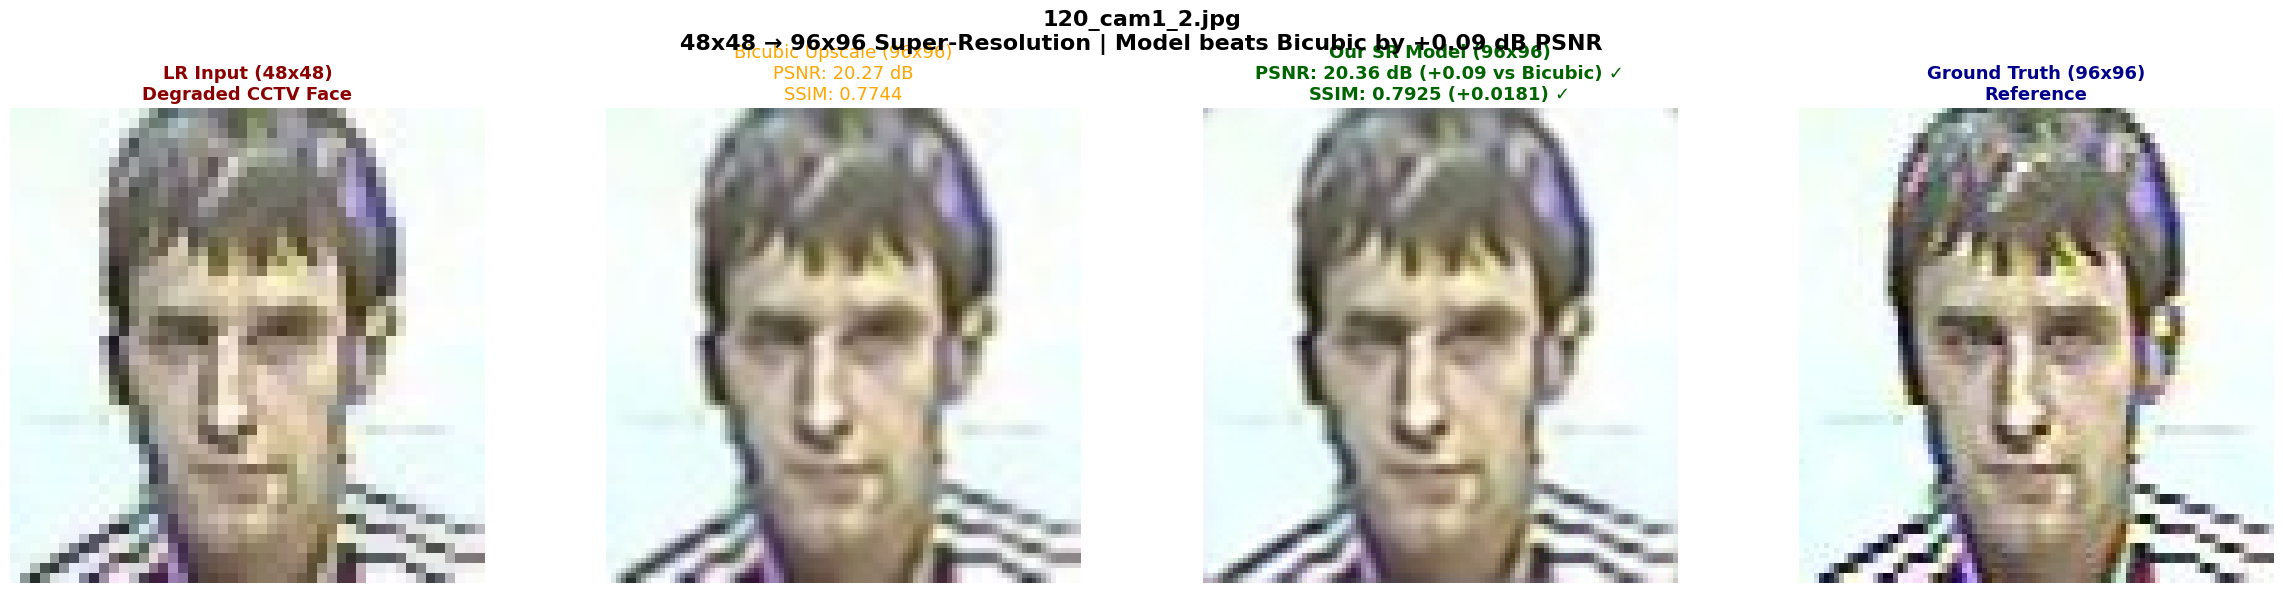


[2/5] 126_cam5_2.jpg


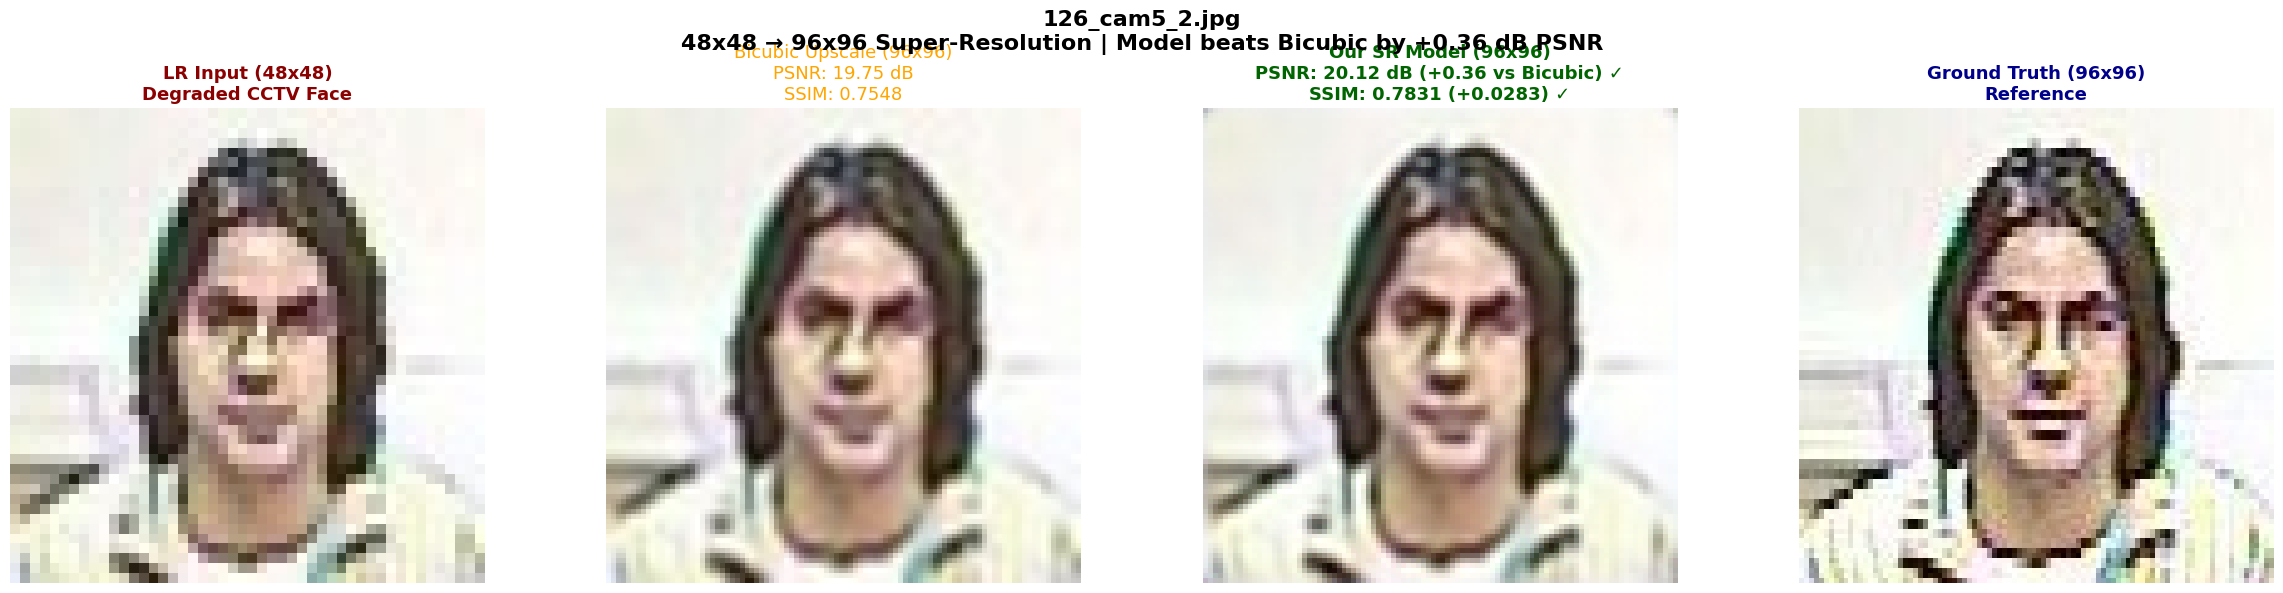


[3/5] 129_cam4_1.jpg


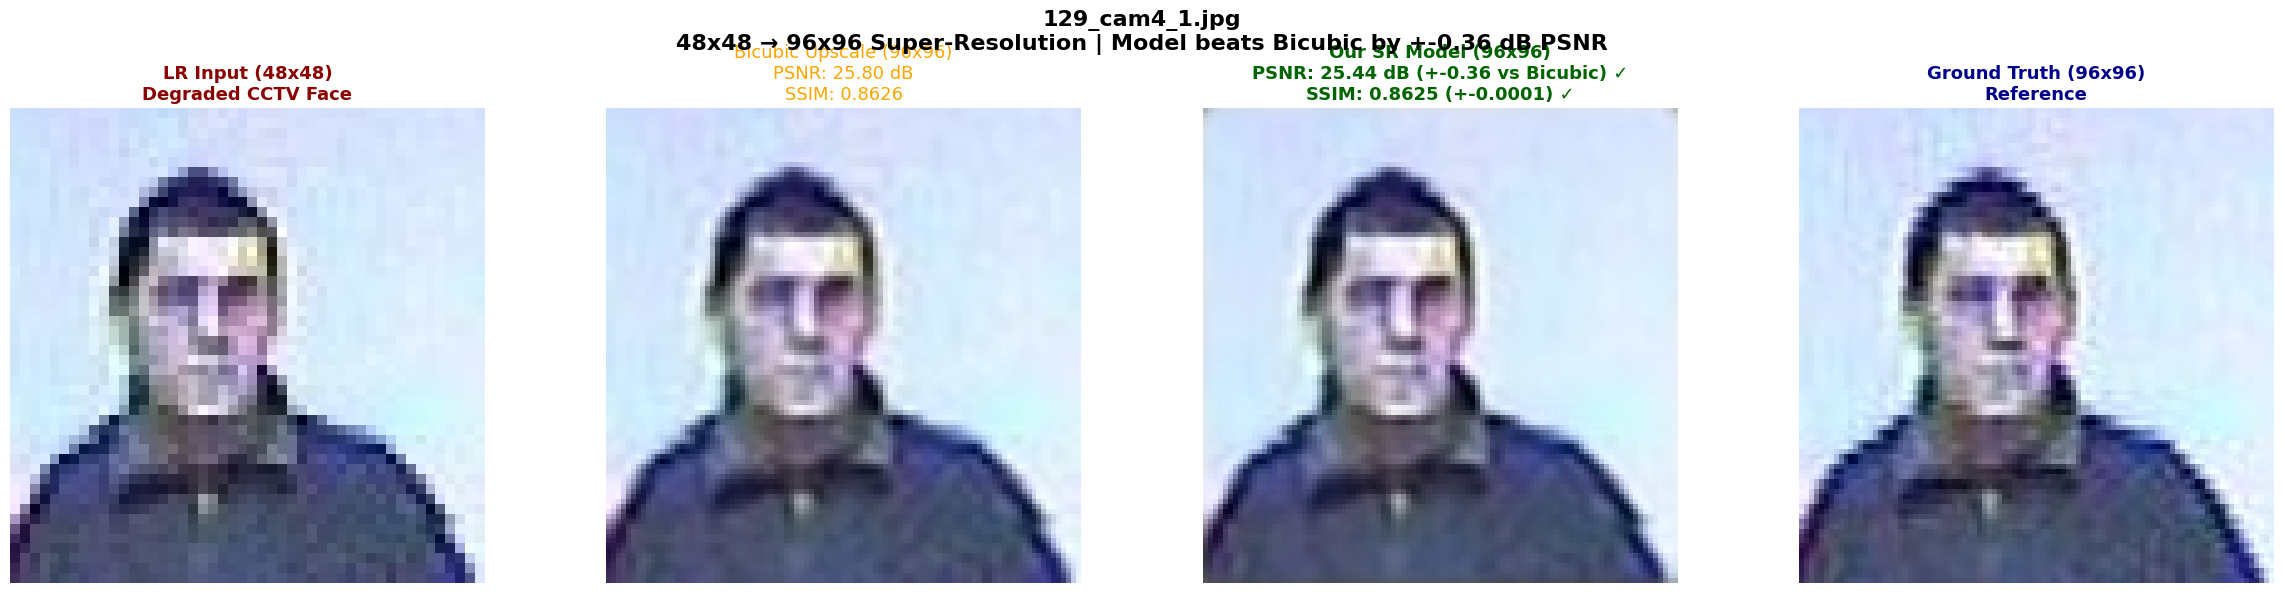


[4/5] 119_cam5_2.jpg


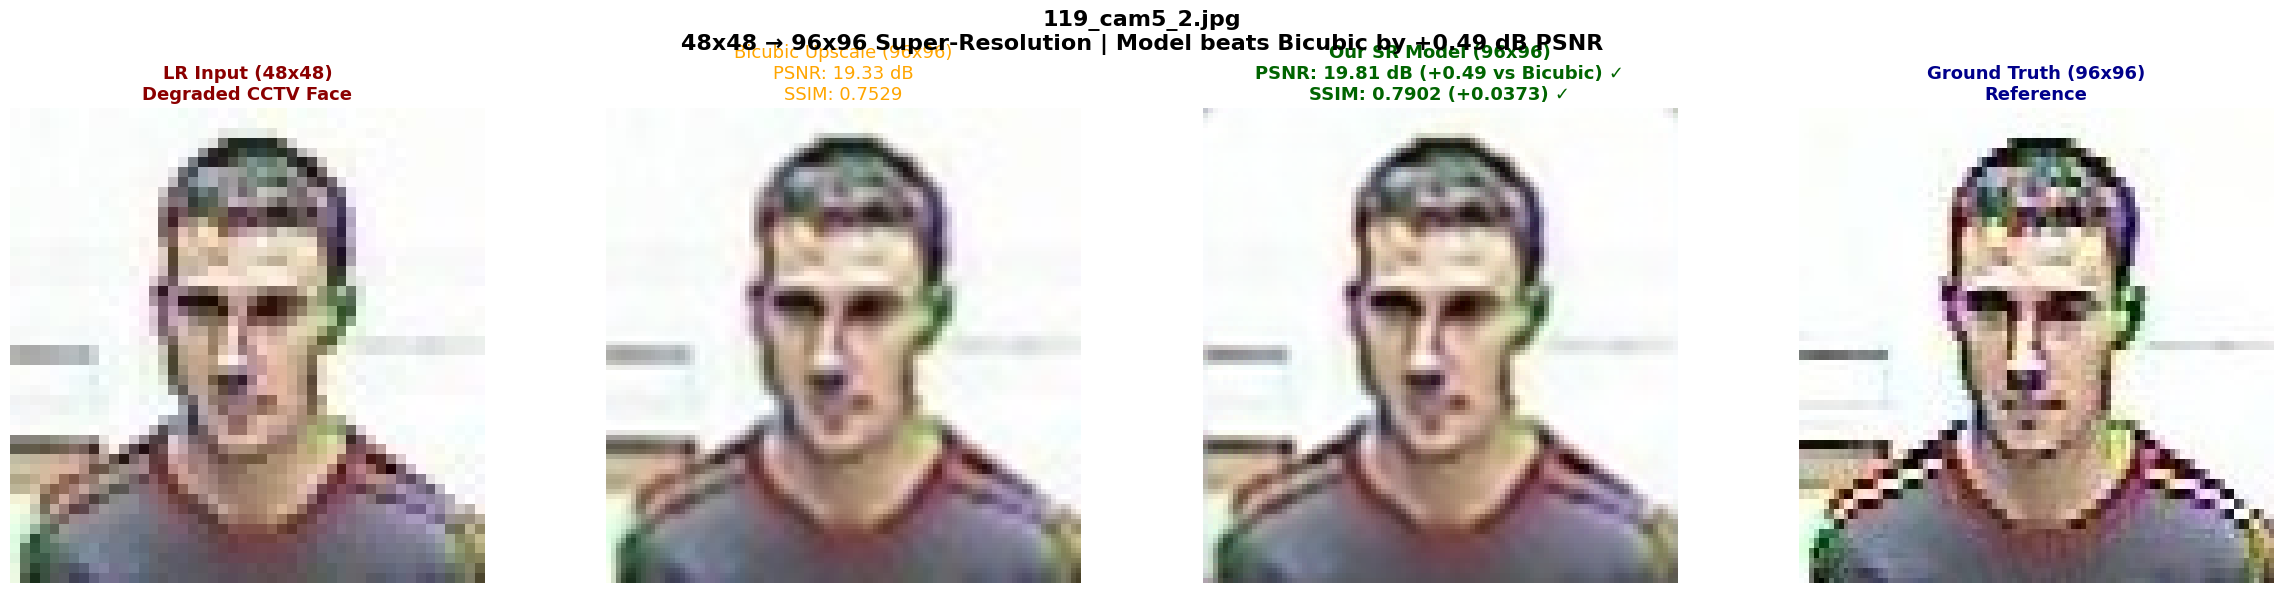


[5/5] 114_cam6_3.jpg


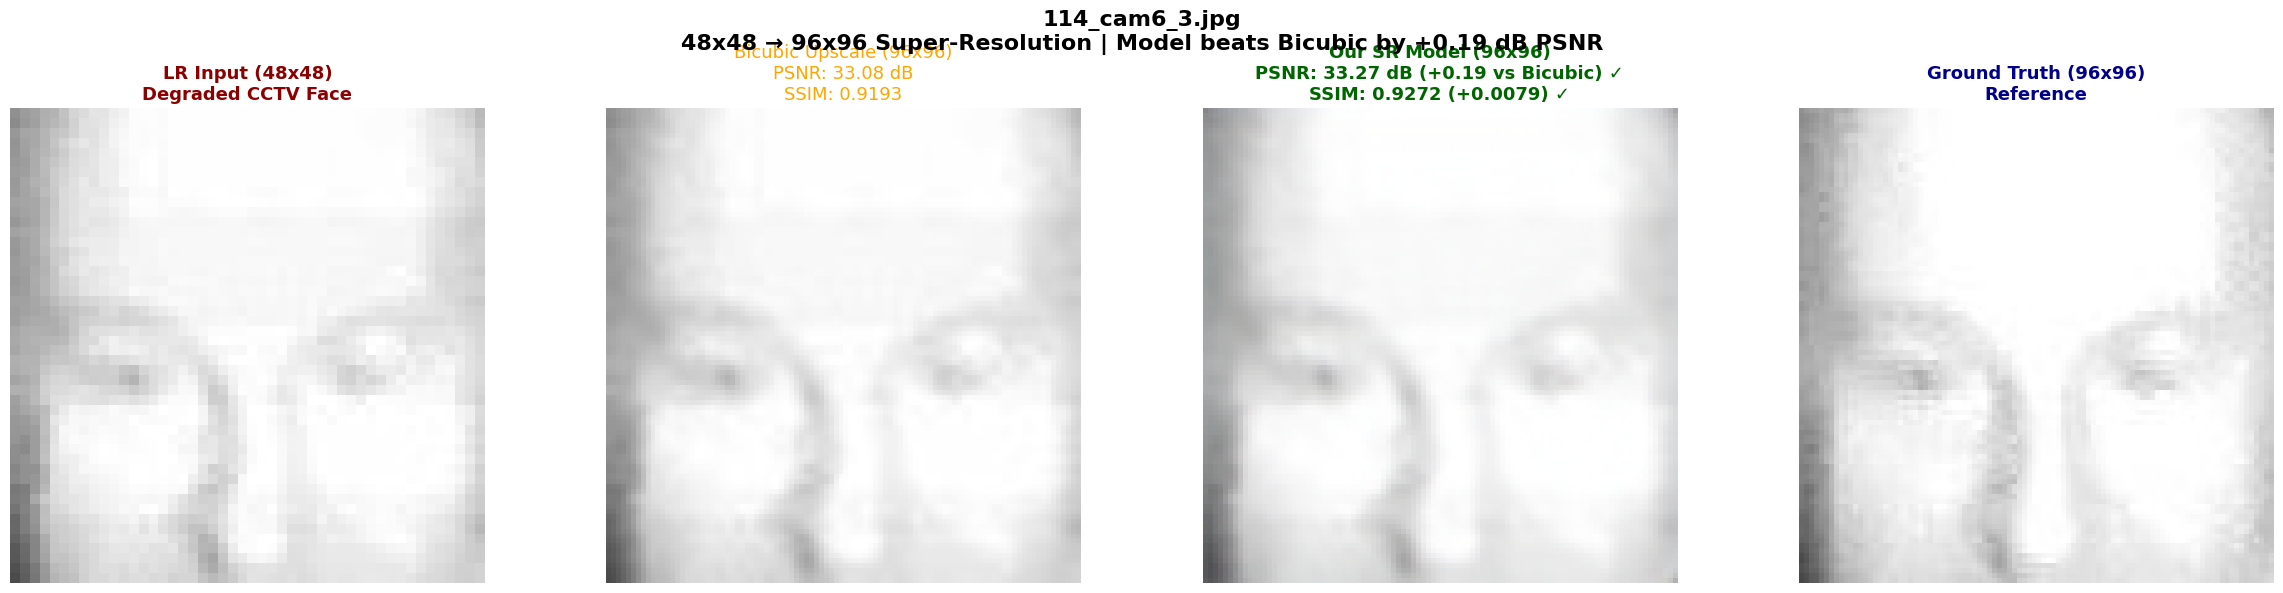


DISPLAYING RANDOM TEST SAMPLES (3-PANEL SIMPLIFIED)

[1/5] 120_cam1_2.jpg


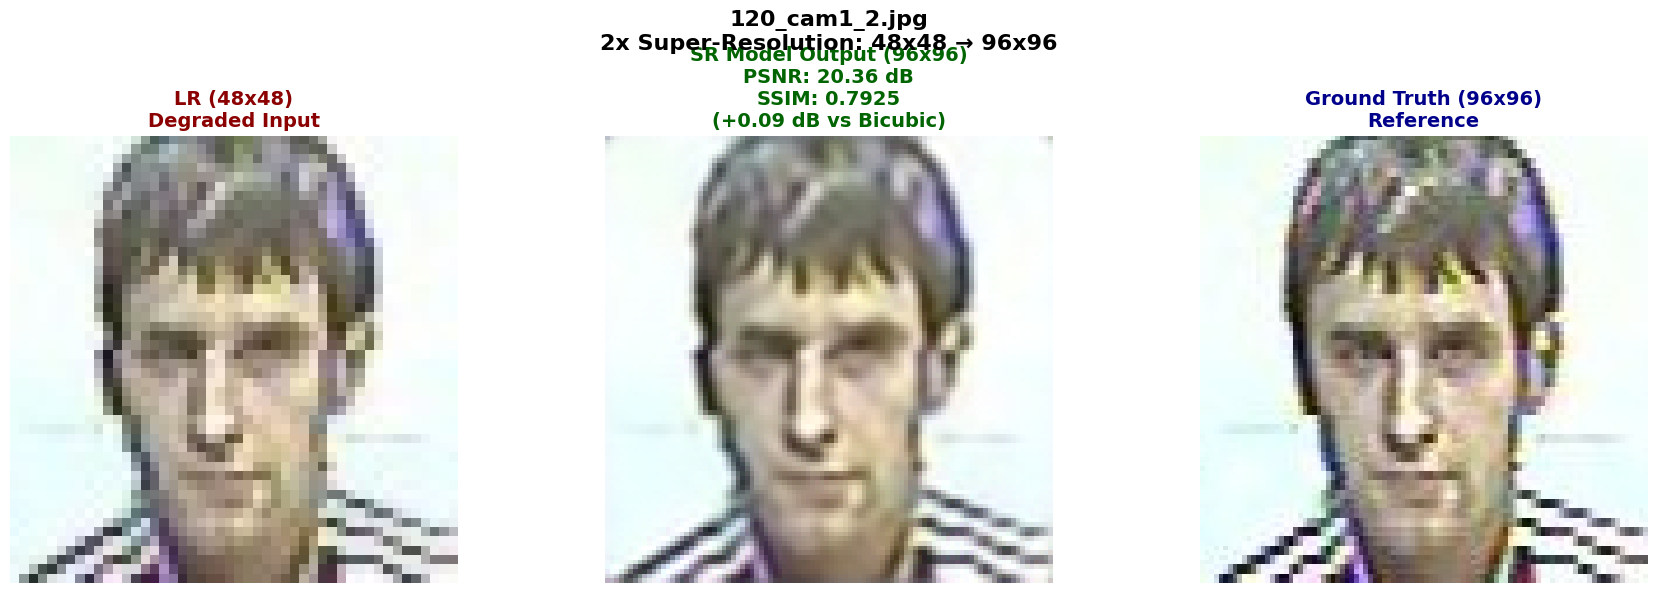


[2/5] 126_cam5_2.jpg


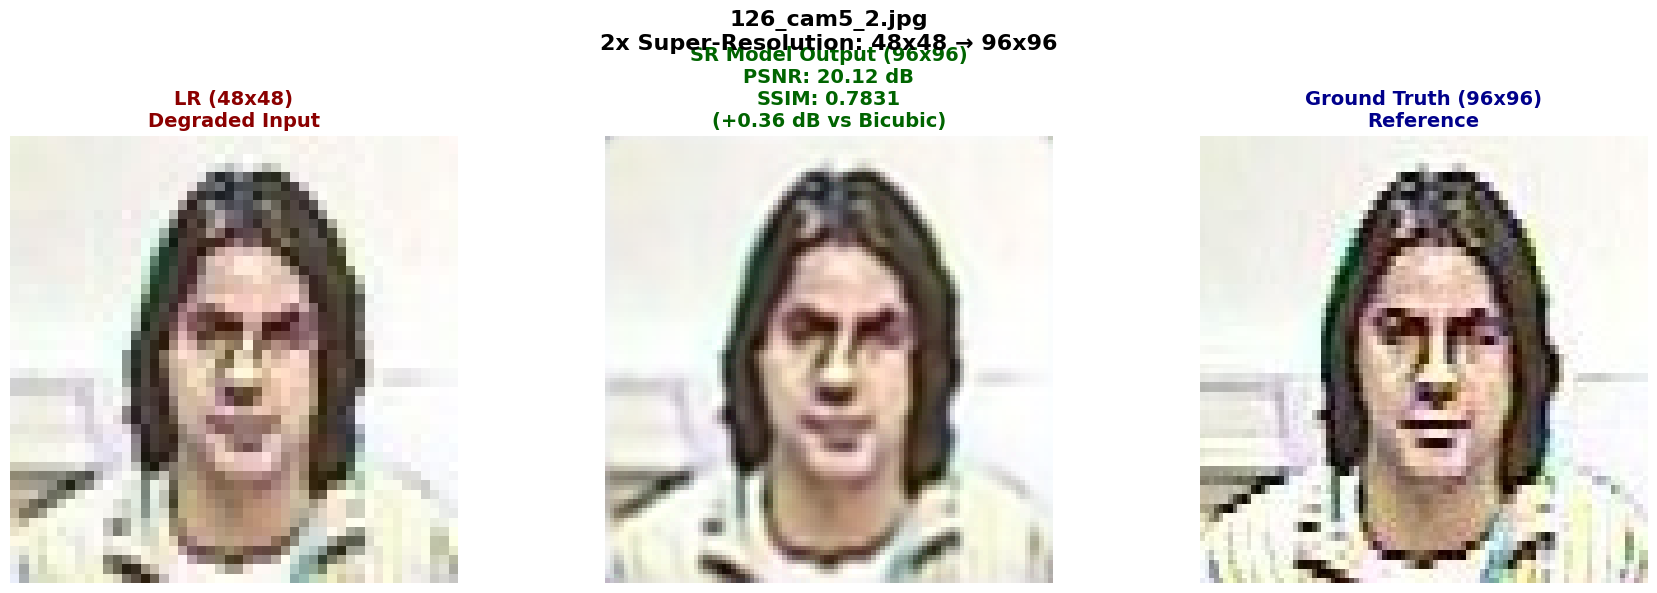


[3/5] 129_cam4_1.jpg


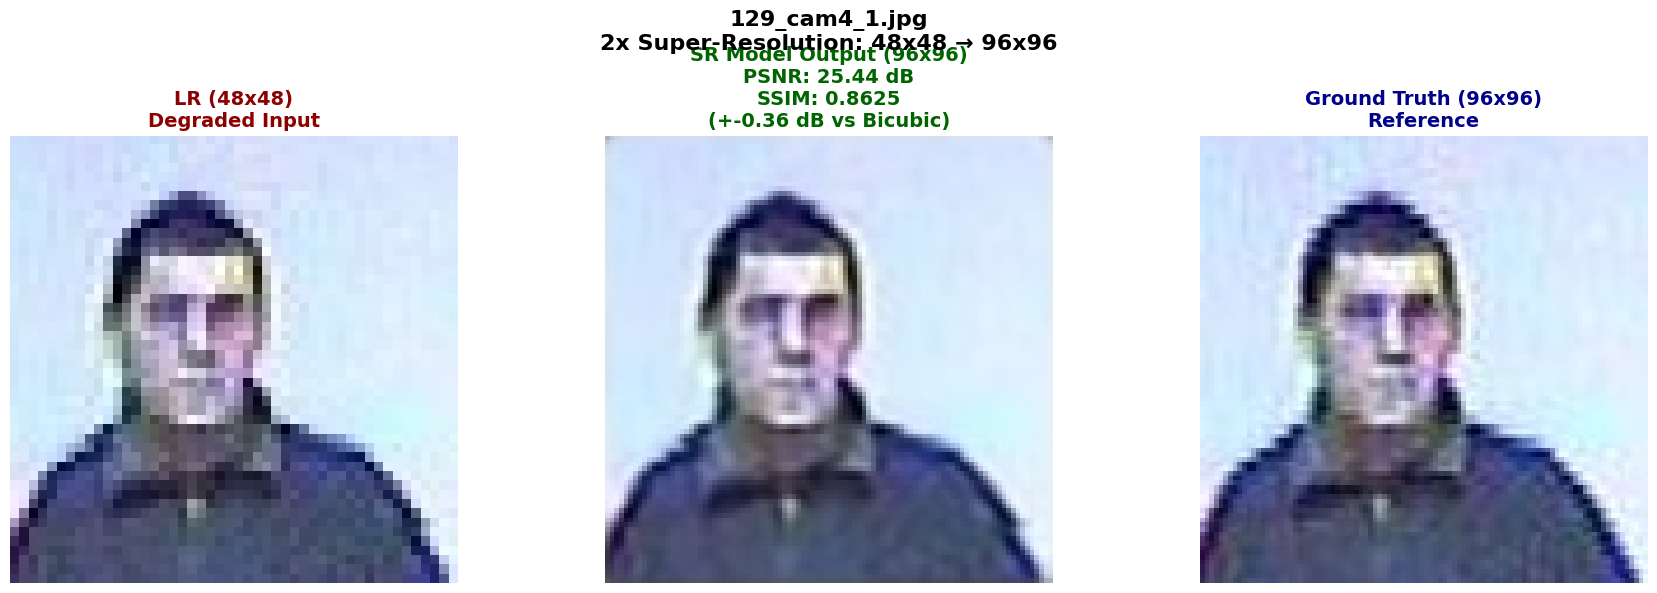


[4/5] 119_cam5_2.jpg


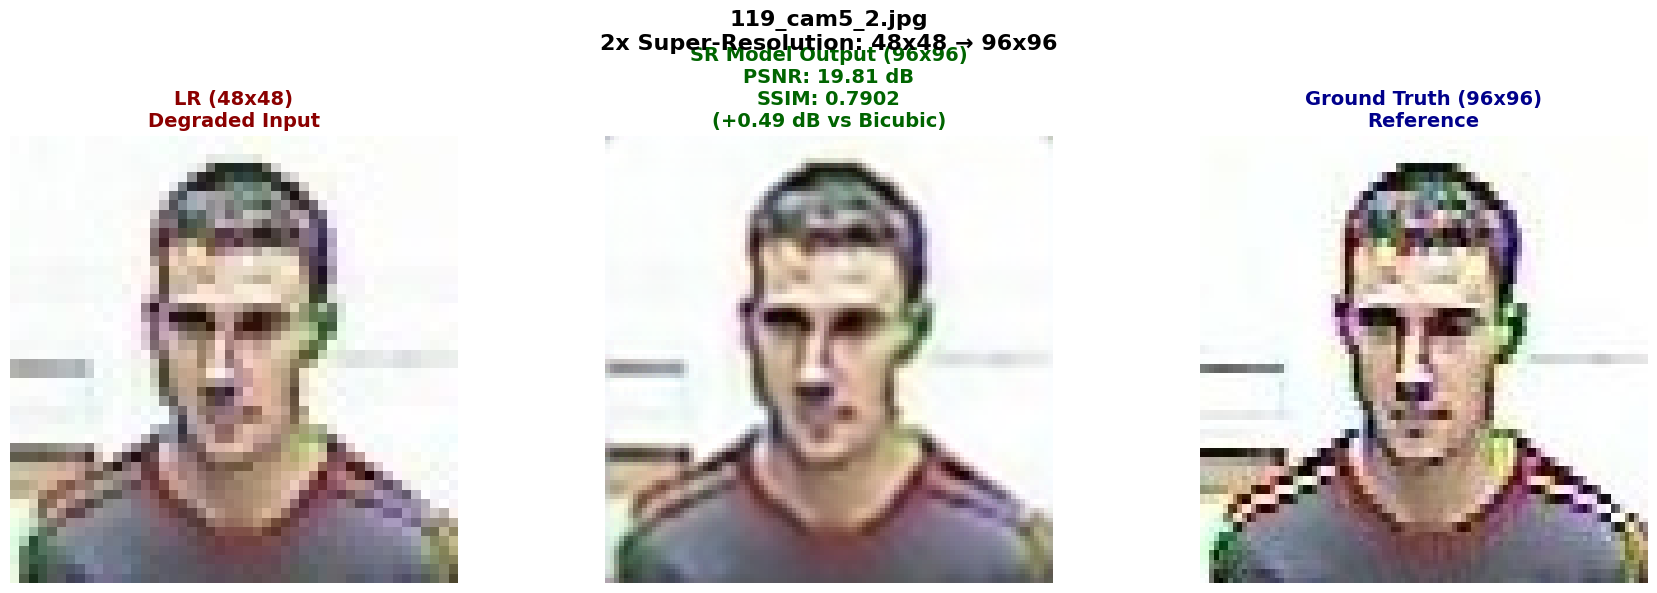


[5/5] 114_cam6_3.jpg


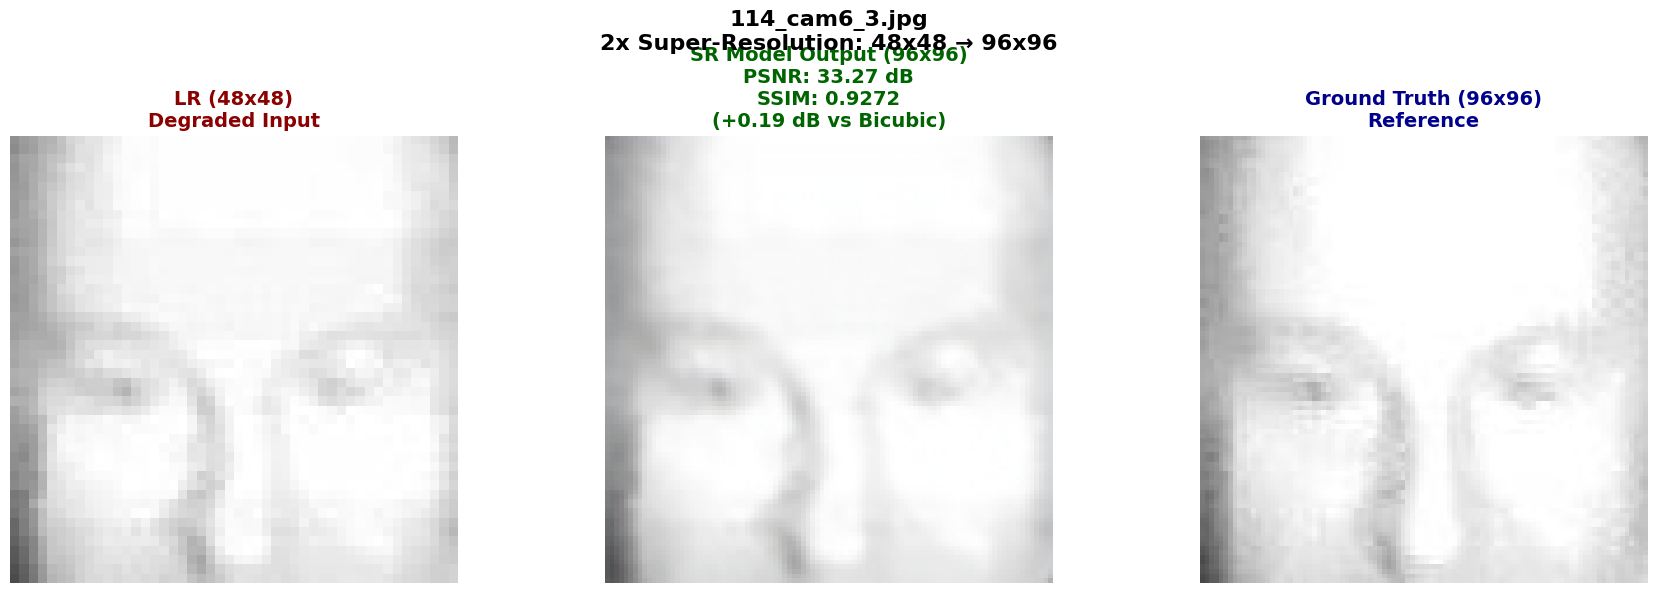


BEST IMPROVEMENTS

[1/3] Best: 114_cam8.jpg (+1.95 dB over Bicubic)


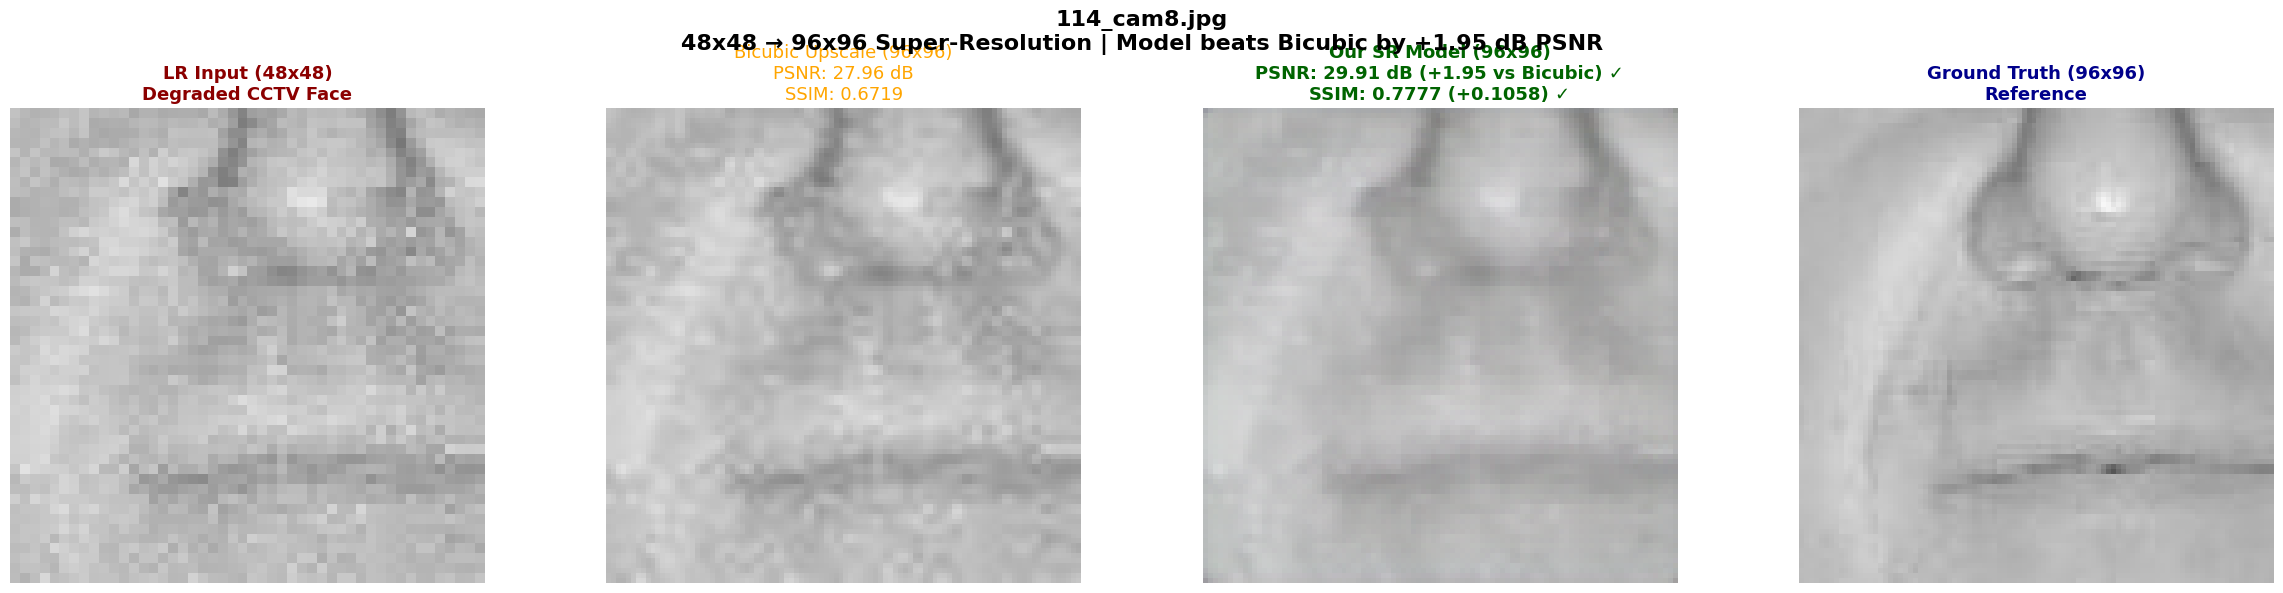


[2/3] Best: 112_cam2_2.jpg (+1.36 dB over Bicubic)


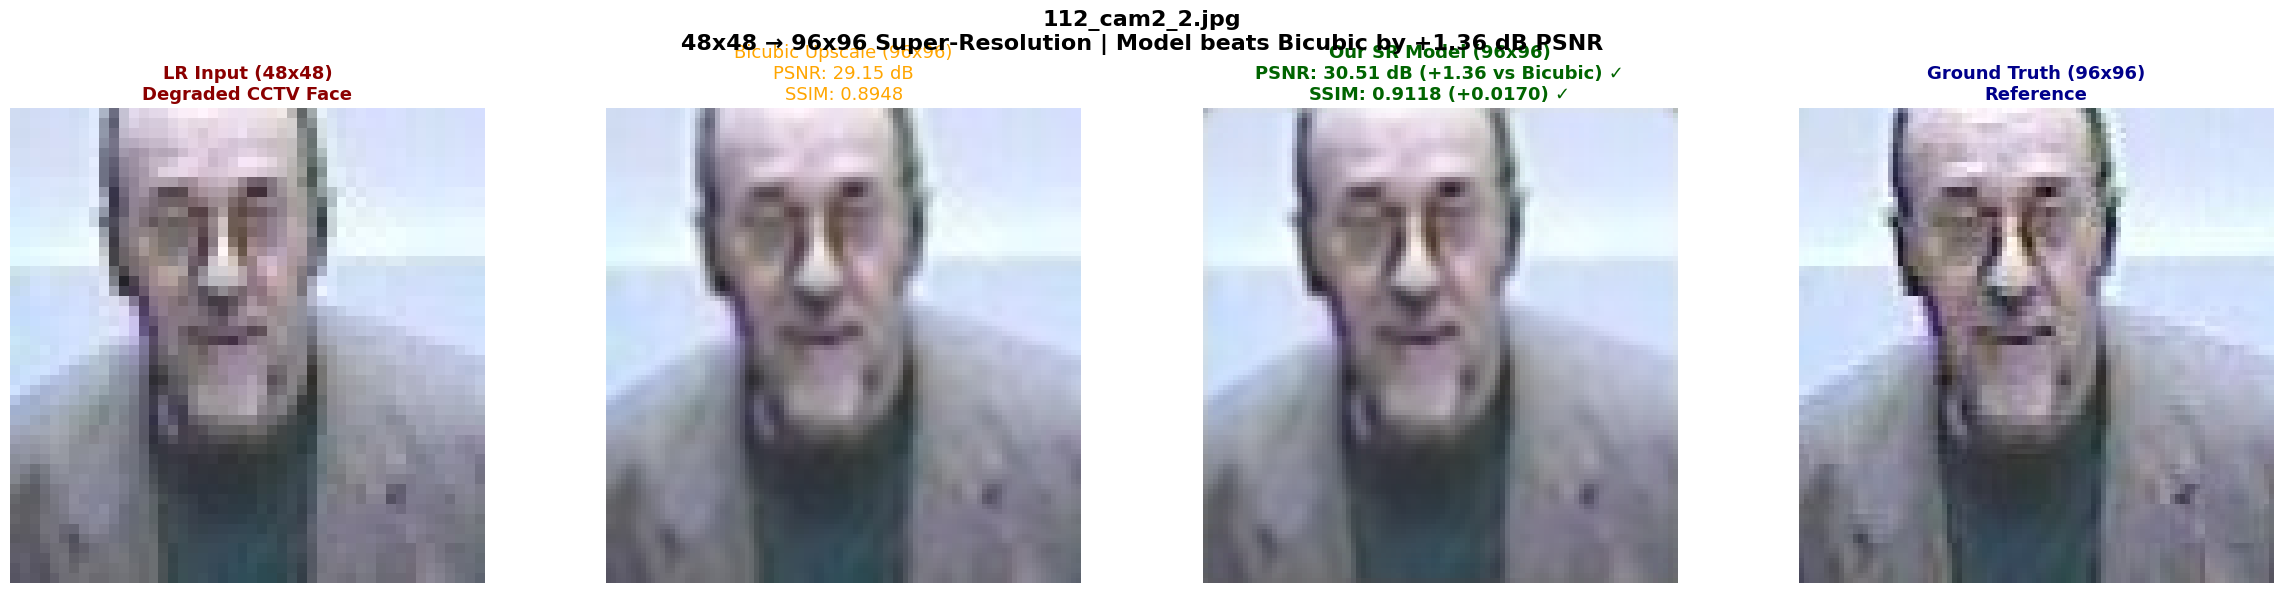


[3/3] Best: 122_cam8.jpg (+1.35 dB over Bicubic)


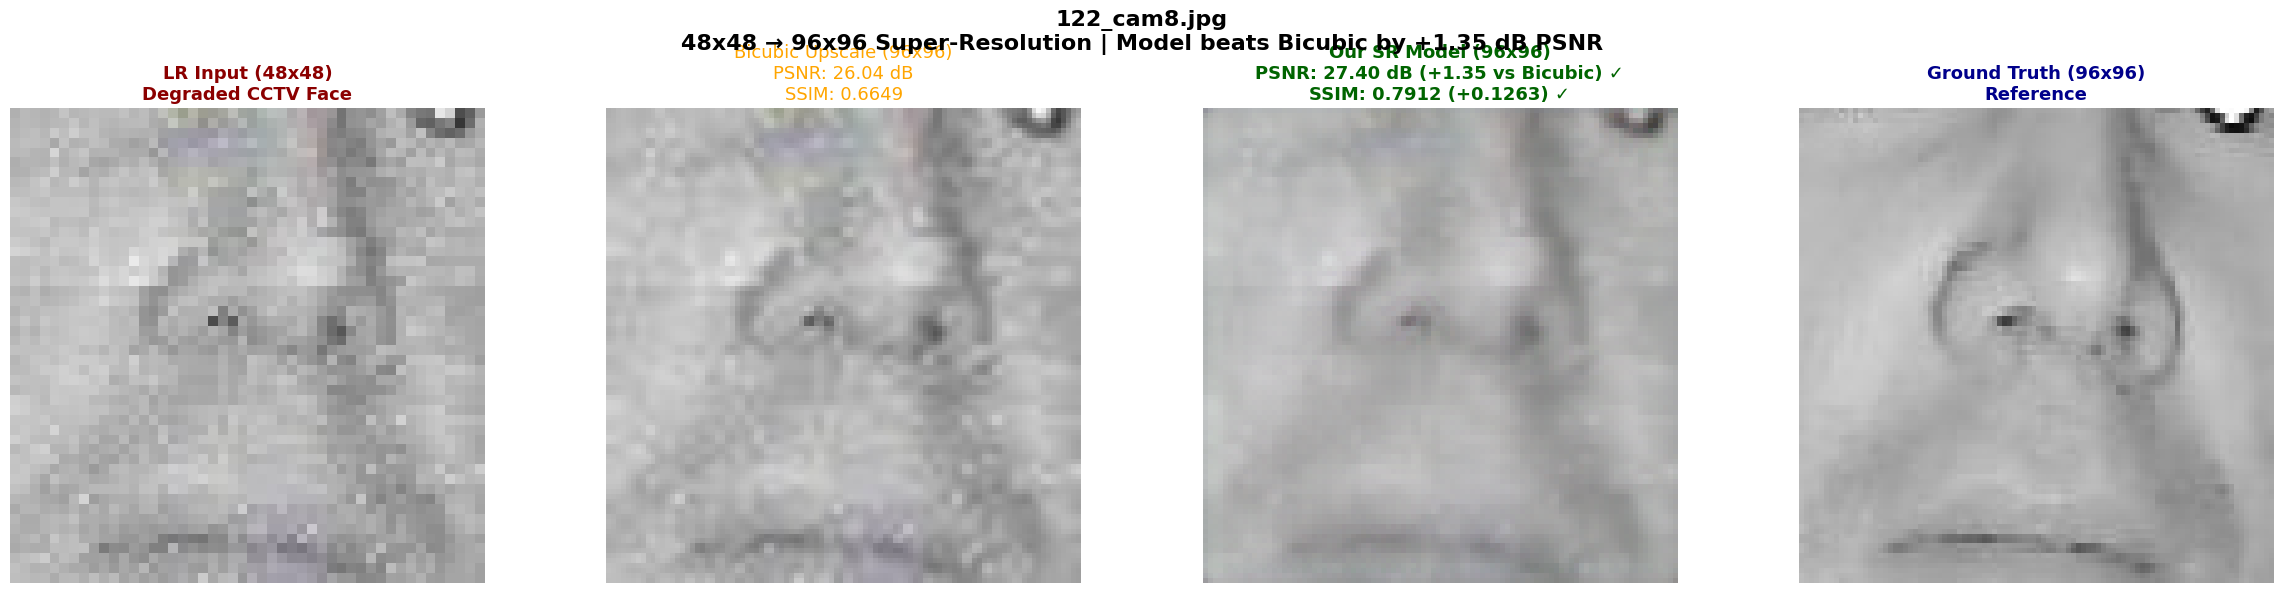


CHALLENGING CASES (Smallest Improvements)

[1/3] Challenging: 128_cam7_1.jpg (+-0.75 dB over Bicubic)


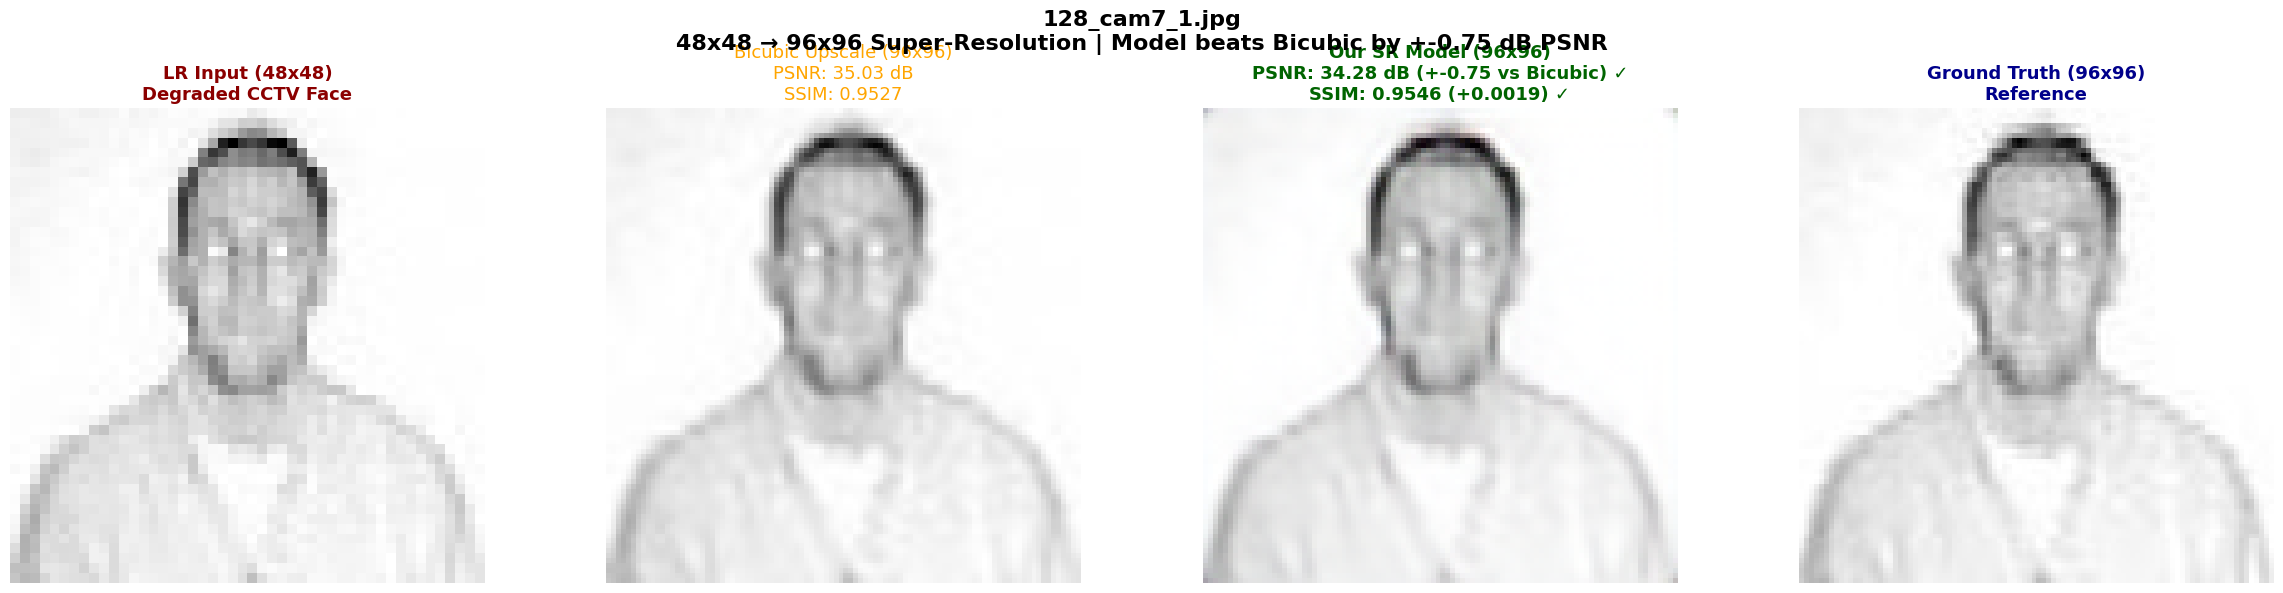


[2/3] Challenging: 120_cam2_1.jpg (+-0.73 dB over Bicubic)


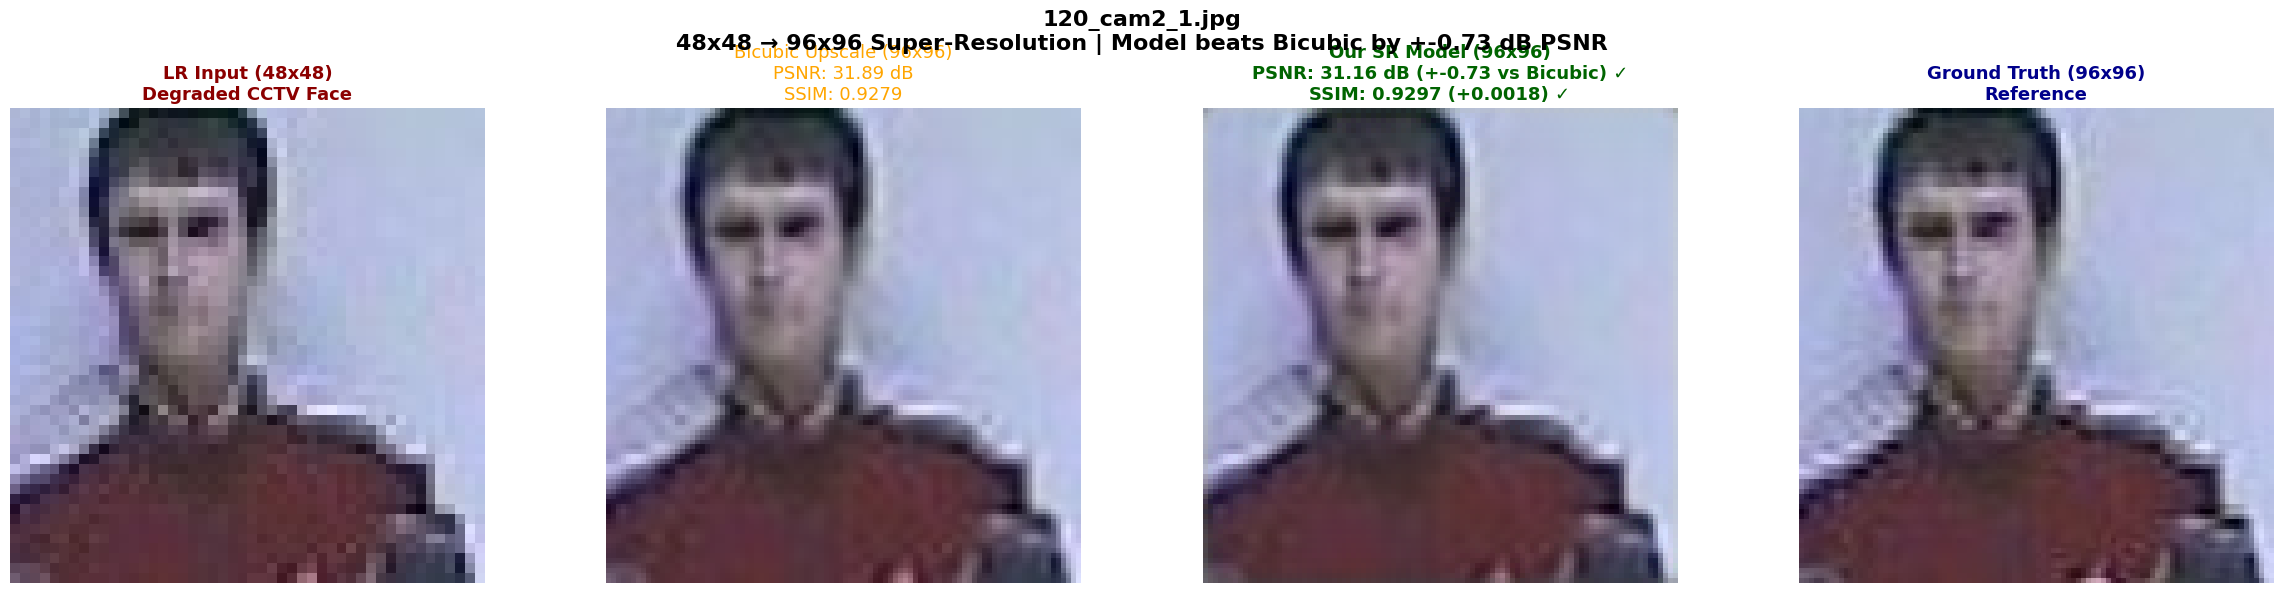


[3/3] Challenging: 112_cam3_1.jpg (+-0.67 dB over Bicubic)


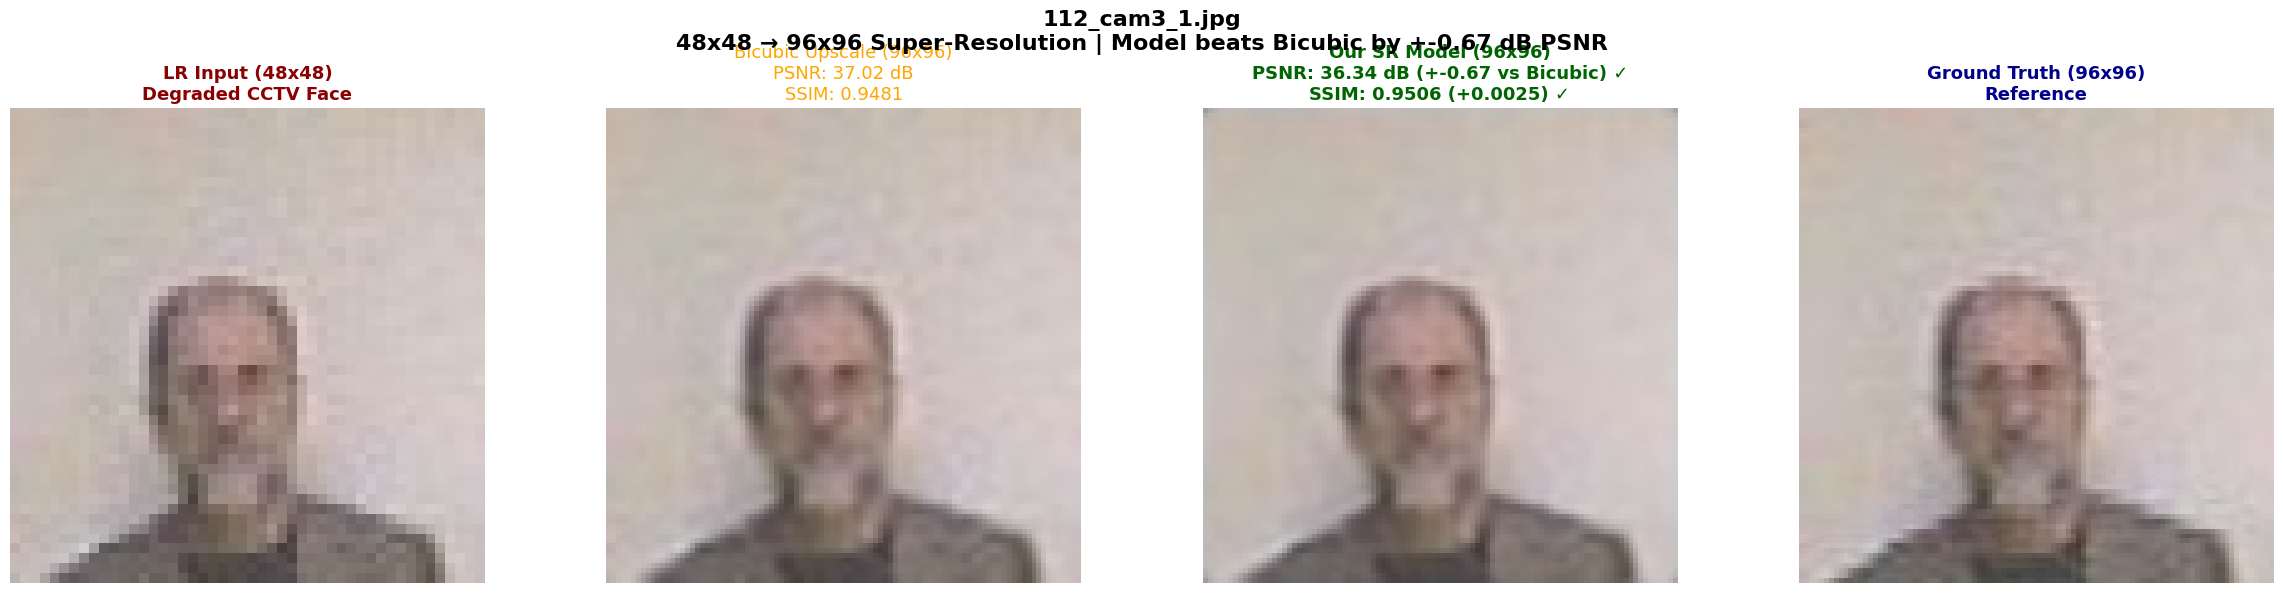


GRID COMPARISON


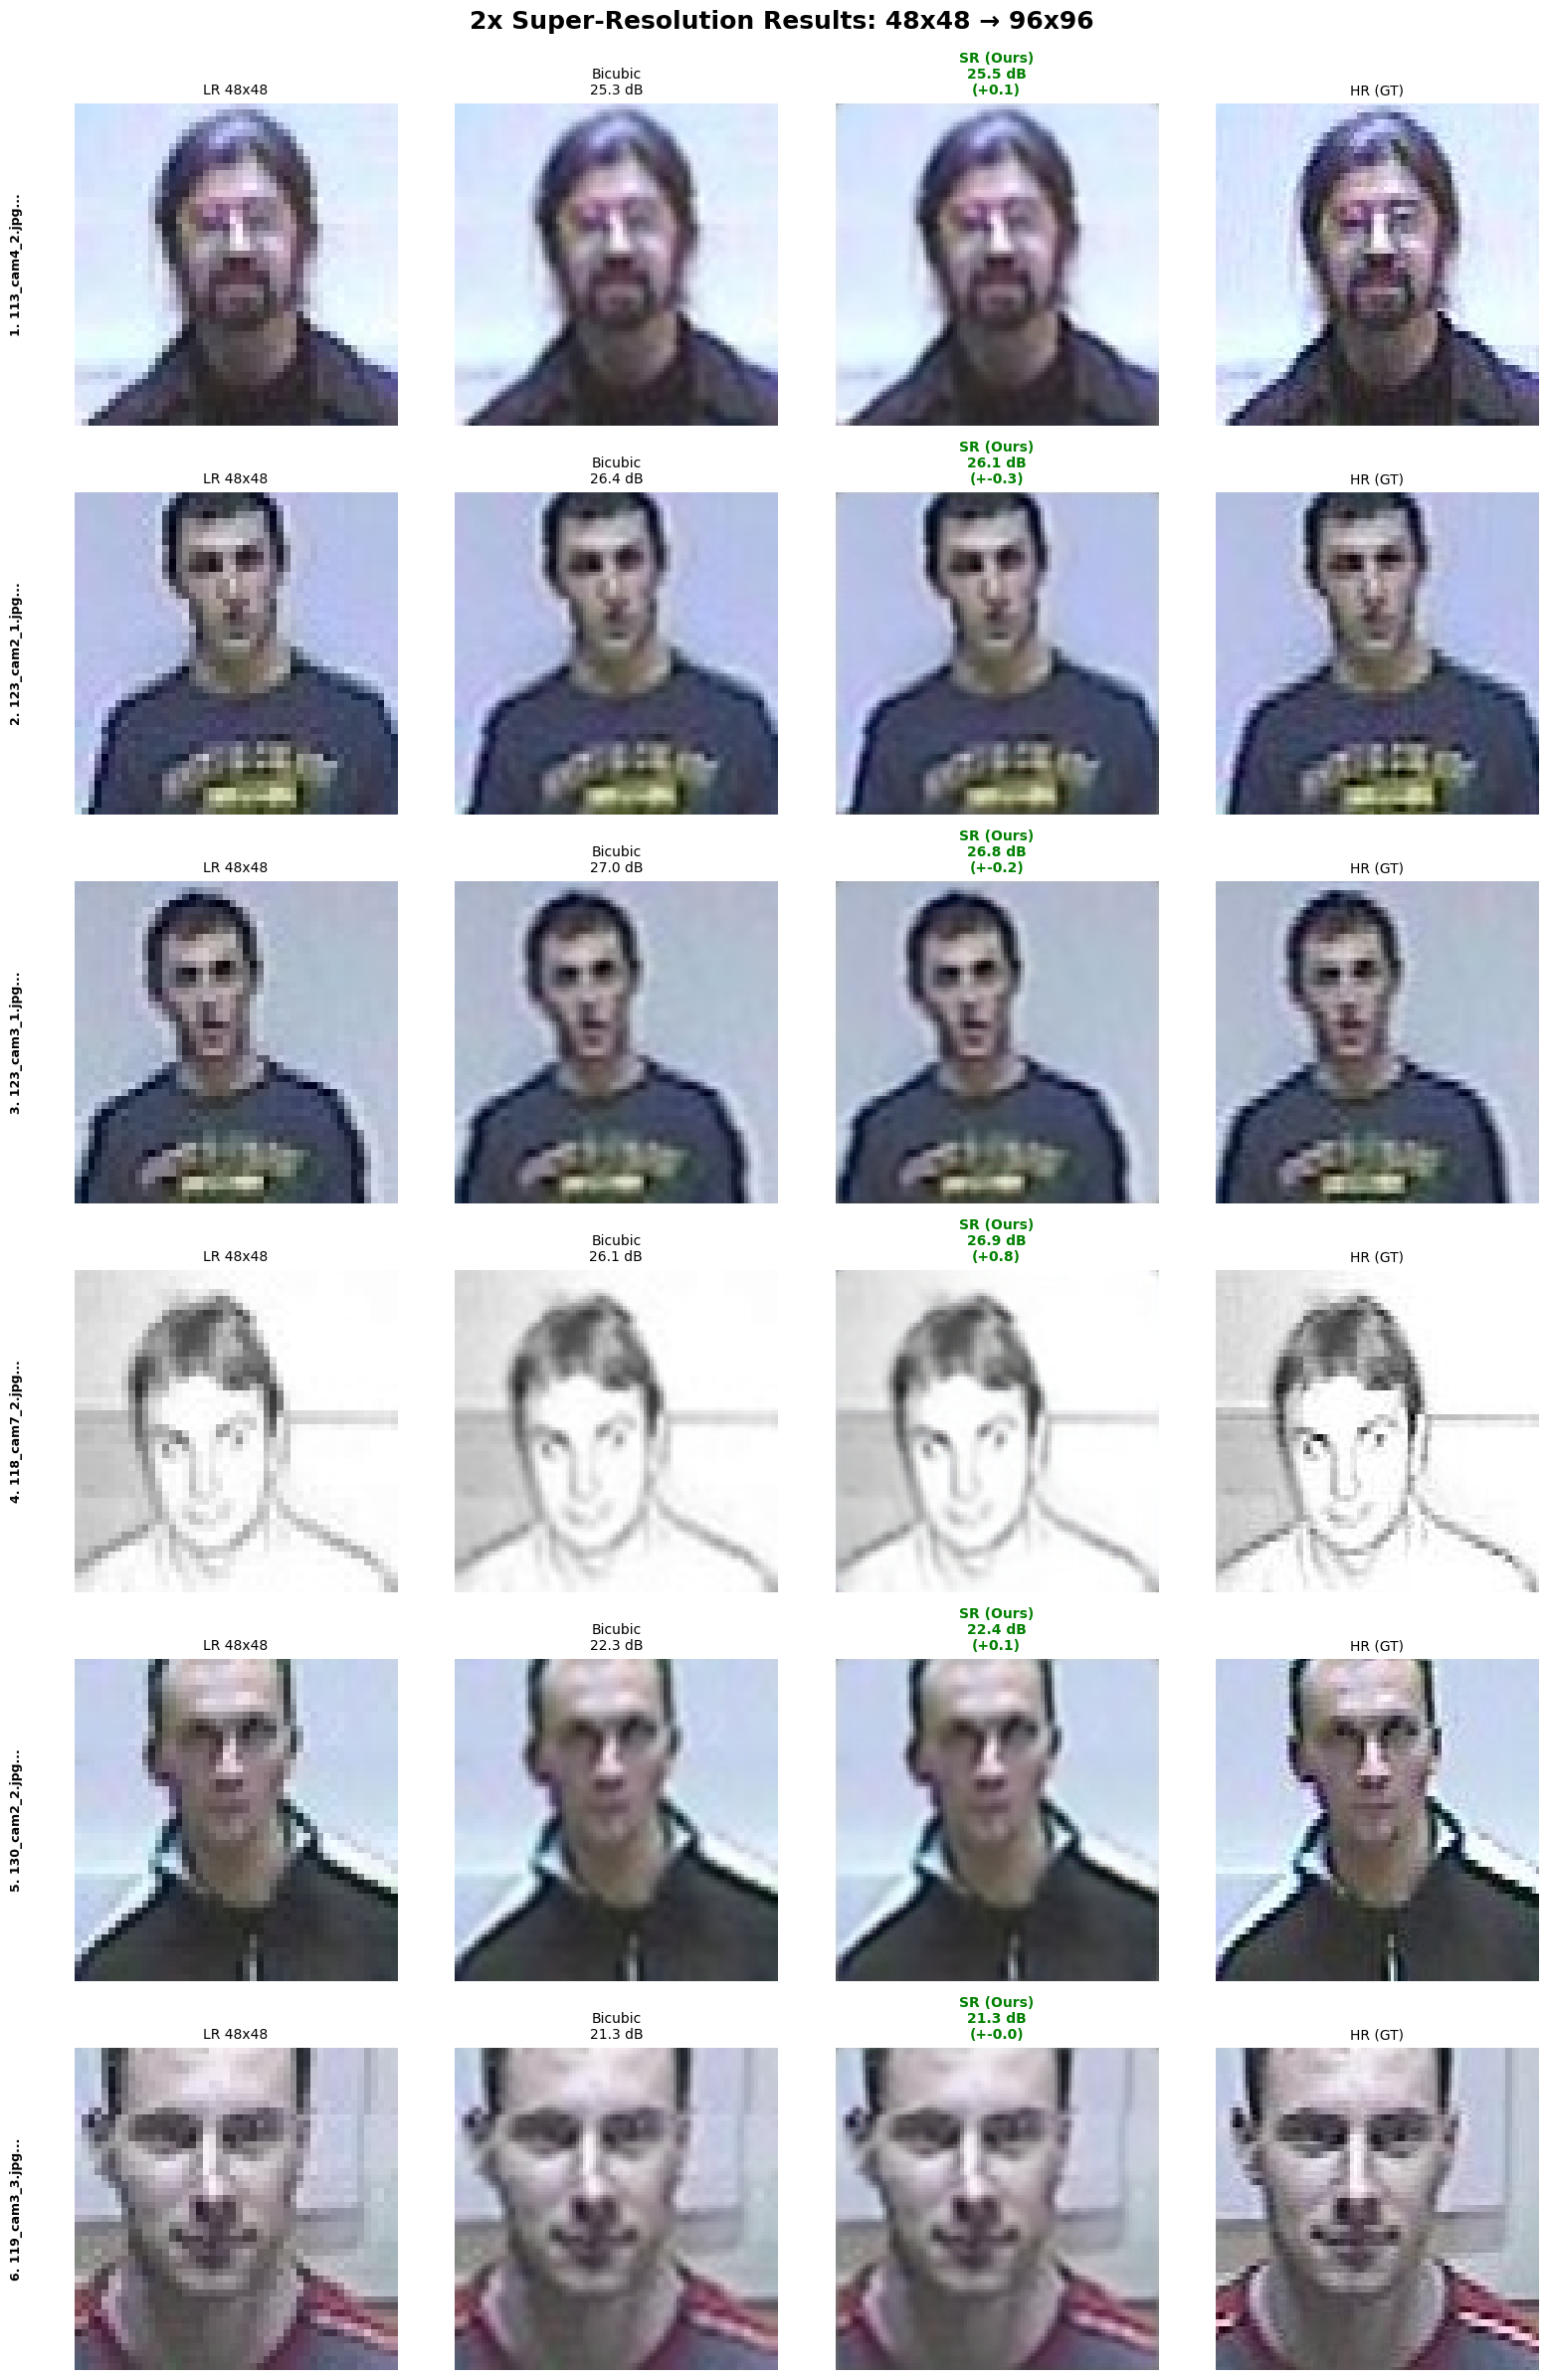


INTERACTIVE BROWSING

Use these functions to browse results:
  show_sr_results(test_images[0])        # 4-panel with Bicubic
  show_sr_results_simple(test_images[0]) # 3-panel simplified
  show_comparison_grid(6)                # Grid of 6 samples

Examples:
  show_sr_results(test_images[10])       # View 11th image
  show_sr_results(test_images[-1])       # View last image
  for i in range(20, 30):
      show_sr_results_simple(test_images[i])  # Browse images 20-30


In [7]:
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np
import random

# ========================================
# DISPLAY FUNCTION FOR 2X SR
# ========================================
def show_sr_results(img_name, save=False):
    """
    Process and display 2x SR results:
    - LR: 48x48 degraded
    - Bicubic: 48→96 simple upscale (baseline)
    - SR: 48→96 our model (restoration + SR)
    - HR: 96x96 ground truth
    """
    
    lr_path = os.path.join(test_lr_dir, img_name)
    hr_path = os.path.join(test_hr_dir, img_name)
    
    result = process_image(lr_path, hr_path)
    
    improvement_psnr = result['psnr_sr'] - result['psnr_bicubic']
    improvement_ssim = result['ssim_sr'] - result['ssim_bicubic']
    
    # Display 4-panel comparison
    fig, axes = plt.subplots(1, 4, figsize=(24, 6))
    
    # LR 48x48 (original degraded input)
    axes[0].imshow(result['lr_img'])
    axes[0].set_title(f'LR Input (48x48)\nDegraded CCTV Face', 
                      fontsize=13, color='darkred', fontweight='bold')
    axes[0].axis('off')
    
    # Bicubic 96x96 (baseline)
    axes[1].imshow(result['lr_upscaled'])
    axes[1].set_title(f'Bicubic Upscale (96x96)\nPSNR: {result["psnr_bicubic"]:.2f} dB\nSSIM: {result["ssim_bicubic"]:.4f}', 
                      fontsize=13, color='orange')
    axes[1].axis('off')
    
    # SR 96x96 (our model)
    axes[2].imshow(result['sr_img'])
    axes[2].set_title(f'Our SR Model (96x96)\nPSNR: {result["psnr_sr"]:.2f} dB (+{improvement_psnr:.2f} vs Bicubic) ✓\nSSIM: {result["ssim_sr"]:.4f} (+{improvement_ssim:.4f}) ✓', 
                      fontsize=13, fontweight='bold', color='darkgreen')
    axes[2].axis('off')
    
    # HR 96x96 (ground truth)
    axes[3].imshow(result['hr_img'])
    axes[3].set_title(f'Ground Truth (96x96)\nReference', 
                      fontsize=13, color='darkblue', fontweight='bold')
    axes[3].axis('off')
    
    # Add overall title
    fig.suptitle(f'{img_name}\n' + 
                 f'48x48 → 96x96 Super-Resolution | Model beats Bicubic by +{improvement_psnr:.2f} dB PSNR',
                 fontsize=16, fontweight='bold', y=0.98)
    
    plt.tight_layout()
    
    if save:
        save_path = os.path.join(checkpoint_dir, f'interactive_display_{img_name}')
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"Saved to {save_path}")
    
    plt.show()

# ========================================
# ALTERNATIVE: 3-PANEL VERSION (SIMPLIFIED)
# ========================================
def show_sr_results_simple(img_name, save=False):
    """Simplified 3-panel version: LR → SR → HR"""
    
    lr_path = os.path.join(test_lr_dir, img_name)
    hr_path = os.path.join(test_hr_dir, img_name)
    
    result = process_image(lr_path, hr_path)
    
    improvement_psnr = result['psnr_sr'] - result['psnr_bicubic']
    improvement_ssim = result['ssim_sr'] - result['ssim_bicubic']
    
    # Display 3-panel comparison
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    
    # LR 48x48
    axes[0].imshow(result['lr_img'])
    axes[0].set_title(f'LR (48x48)\nDegraded Input', 
                      fontsize=14, color='darkred', fontweight='bold')
    axes[0].axis('off')
    
    # SR 96x96 (our model)
    axes[1].imshow(result['sr_img'])
    axes[1].set_title(f'SR Model Output (96x96)\nPSNR: {result["psnr_sr"]:.2f} dB\nSSIM: {result["ssim_sr"]:.4f}\n(+{improvement_psnr:.2f} dB vs Bicubic)', 
                      fontsize=14, fontweight='bold', color='darkgreen')
    axes[1].axis('off')
    
    # HR 96x96
    axes[2].imshow(result['hr_img'])
    axes[2].set_title(f'Ground Truth (96x96)\nReference', 
                      fontsize=14, color='darkblue', fontweight='bold')
    axes[2].axis('off')
    
    fig.suptitle(f'{img_name}\n2x Super-Resolution: 48x48 → 96x96',
                 fontsize=16, fontweight='bold', y=0.98)
    
    plt.tight_layout()
    
    if save:
        save_path = os.path.join(checkpoint_dir, f'simple_display_{img_name}')
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"Saved to {save_path}")
    
    plt.show()

# ========================================
# DISPLAY RANDOM SAMPLES (4-PANEL VERSION)
# ========================================
print("\n" + "="*60)
print("DISPLAYING RANDOM TEST SAMPLES (4-PANEL)")
print("="*60)

n_samples = 5
selected_samples = random.sample(test_images, min(n_samples, len(test_images)))

for i, img_name in enumerate(selected_samples):
    print(f"\n[{i+1}/{n_samples}] {img_name}")
    show_sr_results(img_name)

# ========================================
# ALTERNATIVE: SIMPLE 3-PANEL VERSION
# ========================================
print("\n" + "="*60)
print("DISPLAYING RANDOM TEST SAMPLES (3-PANEL SIMPLIFIED)")
print("="*60)

for i, img_name in enumerate(selected_samples):
    print(f"\n[{i+1}/{n_samples}] {img_name}")
    show_sr_results_simple(img_name)

# ========================================
# SHOW BEST AND WORST CASES
# ========================================
print("\n" + "="*60)
print("BEST IMPROVEMENTS")
print("="*60)

# Show top 3 best improvements
for i in range(min(3, len(sorted_results))):
    r = sorted_results[i]
    print(f"\n[{i+1}/3] Best: {r['filename']} (+{r['improvement_psnr']:.2f} dB over Bicubic)")
    show_sr_results(r['filename'])

print("\n" + "="*60)
print("CHALLENGING CASES (Smallest Improvements)")
print("="*60)

# Show cases where improvement was smallest (but still positive!)
for i in range(min(3, len(sorted_results))):
    r = sorted_results[-(i+1)]
    print(f"\n[{i+1}/3] Challenging: {r['filename']} (+{r['improvement_psnr']:.2f} dB over Bicubic)")
    show_sr_results(r['filename'])

# ========================================
# SIDE-BY-SIDE COMPARISON GRID
# ========================================
def show_comparison_grid(num_samples=6):
    """Show multiple samples in a compact grid"""
    
    samples = random.sample(test_images, min(num_samples, len(test_images)))
    
    fig, axes = plt.subplots(num_samples, 4, figsize=(16, 4*num_samples))
    
    if num_samples == 1:
        axes = axes.reshape(1, -1)
    
    fig.suptitle('2x Super-Resolution Results: 48x48 → 96x96', 
                 fontsize=18, fontweight='bold', y=0.995)
    
    for idx, img_name in enumerate(samples):
        lr_path = os.path.join(test_lr_dir, img_name)
        hr_path = os.path.join(test_hr_dir, img_name)
        
        result = process_image(lr_path, hr_path)
        improvement = result['psnr_sr'] - result['psnr_bicubic']
        
        # LR
        axes[idx, 0].imshow(result['lr_img'])
        axes[idx, 0].set_title('LR 48x48', fontsize=10)
        axes[idx, 0].axis('off')
        
        # Bicubic
        axes[idx, 1].imshow(result['lr_upscaled'])
        axes[idx, 1].set_title(f'Bicubic\n{result["psnr_bicubic"]:.1f} dB', fontsize=10)
        axes[idx, 1].axis('off')
        
        # SR
        axes[idx, 2].imshow(result['sr_img'])
        axes[idx, 2].set_title(f'SR (Ours)\n{result["psnr_sr"]:.1f} dB\n(+{improvement:.1f})', 
                               fontsize=10, fontweight='bold', color='green')
        axes[idx, 2].axis('off')
        
        # HR
        axes[idx, 3].imshow(result['hr_img'])
        axes[idx, 3].set_title('HR (GT)', fontsize=10)
        axes[idx, 3].axis('off')
        
        # Row label
        axes[idx, 0].text(-0.2, 0.5, f'{idx+1}. {img_name[:15]}...', 
                          transform=axes[idx, 0].transAxes,
                          fontsize=9, rotation=90, va='center', fontweight='bold')
    
    plt.tight_layout()
    plt.show()

print("\n" + "="*60)
print("GRID COMPARISON")
print("="*60)
show_comparison_grid(num_samples=6)

# ========================================
# INTERACTIVE BROWSING
# ========================================
print("\n" + "="*60)
print("INTERACTIVE BROWSING")
print("="*60)
print("\nUse these functions to browse results:")
print("  show_sr_results(test_images[0])        # 4-panel with Bicubic")
print("  show_sr_results_simple(test_images[0]) # 3-panel simplified")
print("  show_comparison_grid(6)                # Grid of 6 samples")
print("\nExamples:")
print("  show_sr_results(test_images[10])       # View 11th image")
print("  show_sr_results(test_images[-1])       # View last image")
print("  for i in range(20, 30):")
print("      show_sr_results_simple(test_images[i])  # Browse images 20-30")